In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from PIL import Image
import os
from keras.utils import to_categorical
from keras.models import Sequential, load_model
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import warnings
from sklearn.model_selection import GridSearchCV
from sklearn import datasets, svm
from sklearn.svm import SVC, LinearSVC
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from skimage.feature import local_binary_pattern
from skimage.feature import hog
from sklearn.decomposition import PCA

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.inspection import permutation_importance
import seaborn as sns
from sklearn.metrics import f1_score
from collections import Counter


In [50]:
os.chdir("/Users/tasneemzulaiqa/Desktop/university/ML/2025_A2/train")

train_metadata = pd.read_csv("train_metadata.csv")

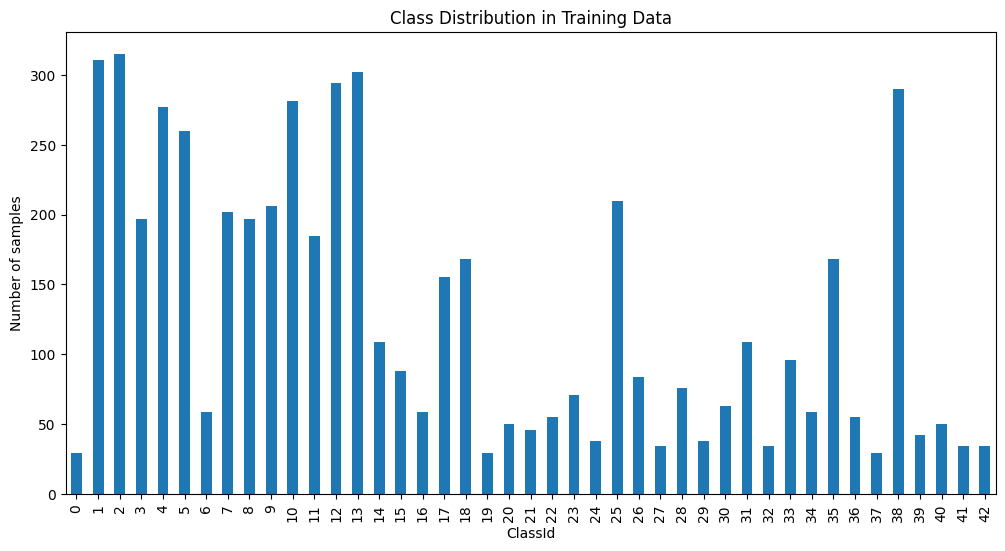

In [51]:
train_metadata['ClassId'].value_counts().sort_index().plot(kind='bar', figsize=(12,6))
plt.xlabel('ClassId')
plt.ylabel('Number of samples')
plt.title('Class Distribution in Training Data')
plt.show()

### FEATURE ENGINEERING

### INITIAL EXPERIMENTATION

In [57]:
# load provided feature files
train_meanrgb = pd.read_csv("Features/additional_features.csv")
train_colour_hist = pd.read_csv("Features/color_histogram.csv")
train_hog_pca = pd.read_csv("Features/hog_pca.csv")

In [58]:
# Merge all features by 'id'
train_df_all = train_metadata.merge(train_meanrgb, on="image_path") \
         .merge(train_colour_hist, on="image_path") \
         .merge(train_hog_pca, on="image_path")

print("Combined dataset shape:", train_df_all.shape)

Combined dataset shape: (5488, 123)


In [59]:
X_all = train_df_all.drop(columns=["ClassId", "id", "image_path"], errors="ignore").values
y = train_df_all["ClassId"].values
feature_names_all = train_df_all.drop(columns=["ClassId", "id", "image_path"], errors="ignore").columns

In [ ]:
X_train_all, X_val_all, y_train, y_val = train_test_split(X_all, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_scaled_train_all = scaler.fit_transform(X_train_all) 
X_scaled_val_all = scaler.transform(X_val_all) 

In [328]:
models = (RandomForestClassifier(
    n_estimators=250,
    max_depth=None,
    min_samples_split=2,
    random_state=42
),svm.SVC(kernel='rbf', gamma=0.01, C=100))

models = (clf.fit(X_scaled_train_all, y_train) for clf in models)

titles = ('Random Forest',
          'SVC with RBF kernel')

for title, model in zip(titles, models):
    train_acc = model.score(X_scaled_train_all , y_train)
    val_acc = model.score(X_scaled_val_all , y_val)
    cv_acc= np.mean(cross_val_score(model, X_scaled_train_all, y_train, cv=5))
    print(title)
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Cross-Validation Accuracy (CV=5): {cv_acc:.4f}")

Random Forest
Training Accuracy: 1.0000
Validation Accuracy: 0.8078
Cross-Validation Accuracy (CV=5): 0.7713
SVC with RBF kernel
Training Accuracy: 1.0000
Validation Accuracy: 0.8525
Cross-Validation Accuracy (CV=5): 0.8205


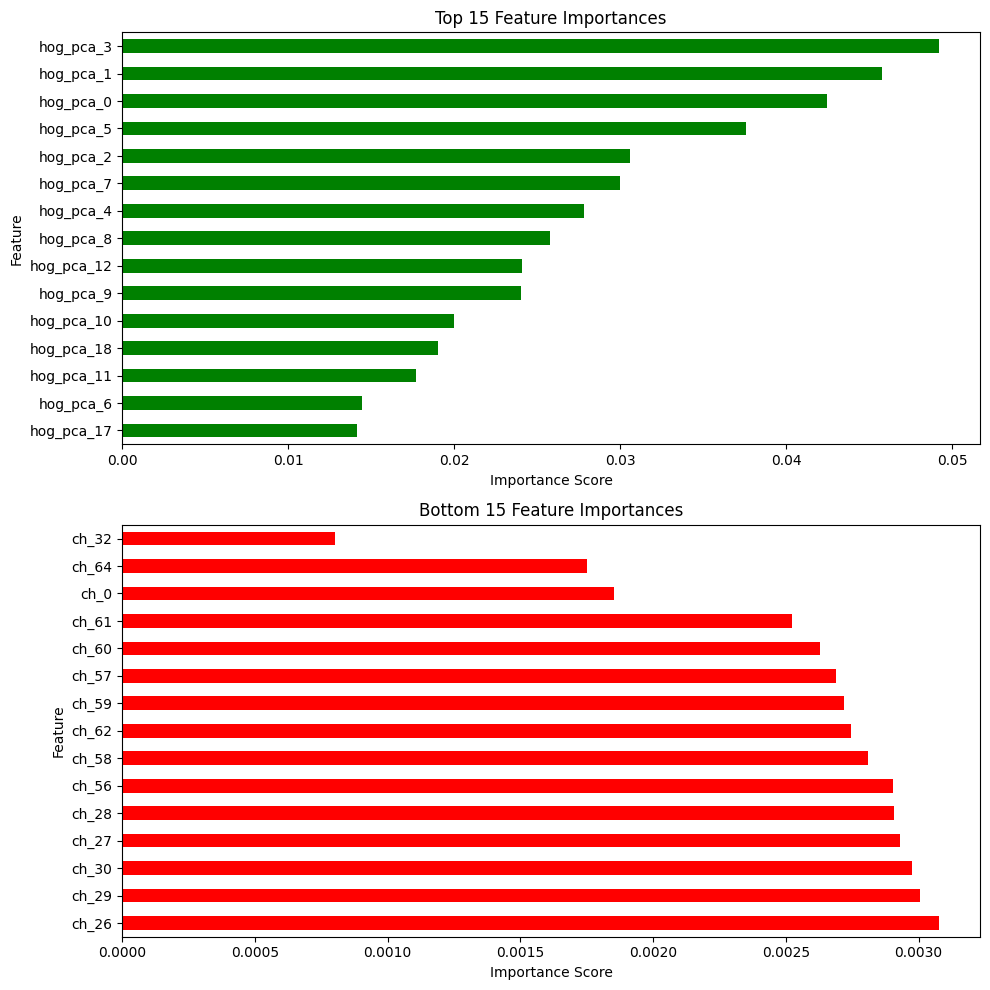

In [ ]:
# show feature importance
r_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)
rf_model.fit(X_scaled_train_all, y_train)
importances = rf_model.feature_importances_
forest_importances = pd.Series(importances, index=feature_names_all)
forest_importances.sort_values(ascending=False)
top_features = forest_importances.nlargest(15)
bottom_features = forest_importances.nsmallest(15)

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

top_features.plot(kind='barh', ax=axes[0], color='green')
axes[0].set_title("Top 15 Feature Importances")
axes[0].set_xlabel("Importance Score")
axes[0].invert_yaxis()  
axes[0].set_ylabel("Feature") 

bottom_features.plot(kind='barh', ax=axes[1], color='red')
axes[1].set_title("Bottom 15 Feature Importances")
axes[1].set_xlabel("Importance Score")
axes[1].invert_yaxis()
axes[1].set_ylabel("Feature")

plt.tight_layout()
plt.show()



/var/folders/59/n7t8nd2s08zcjsn4bd22nlsr0000gn/T/ipykernel_39052/612040532.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="Greens_d", ax=axes[0])
/var/folders/59/n7t8nd2s08zcjsn4bd22nlsr0000gn/T/ipykernel_39052/612040532.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_features.values, y=bottom_features.index, palette="Reds_d", ax=axes[1])


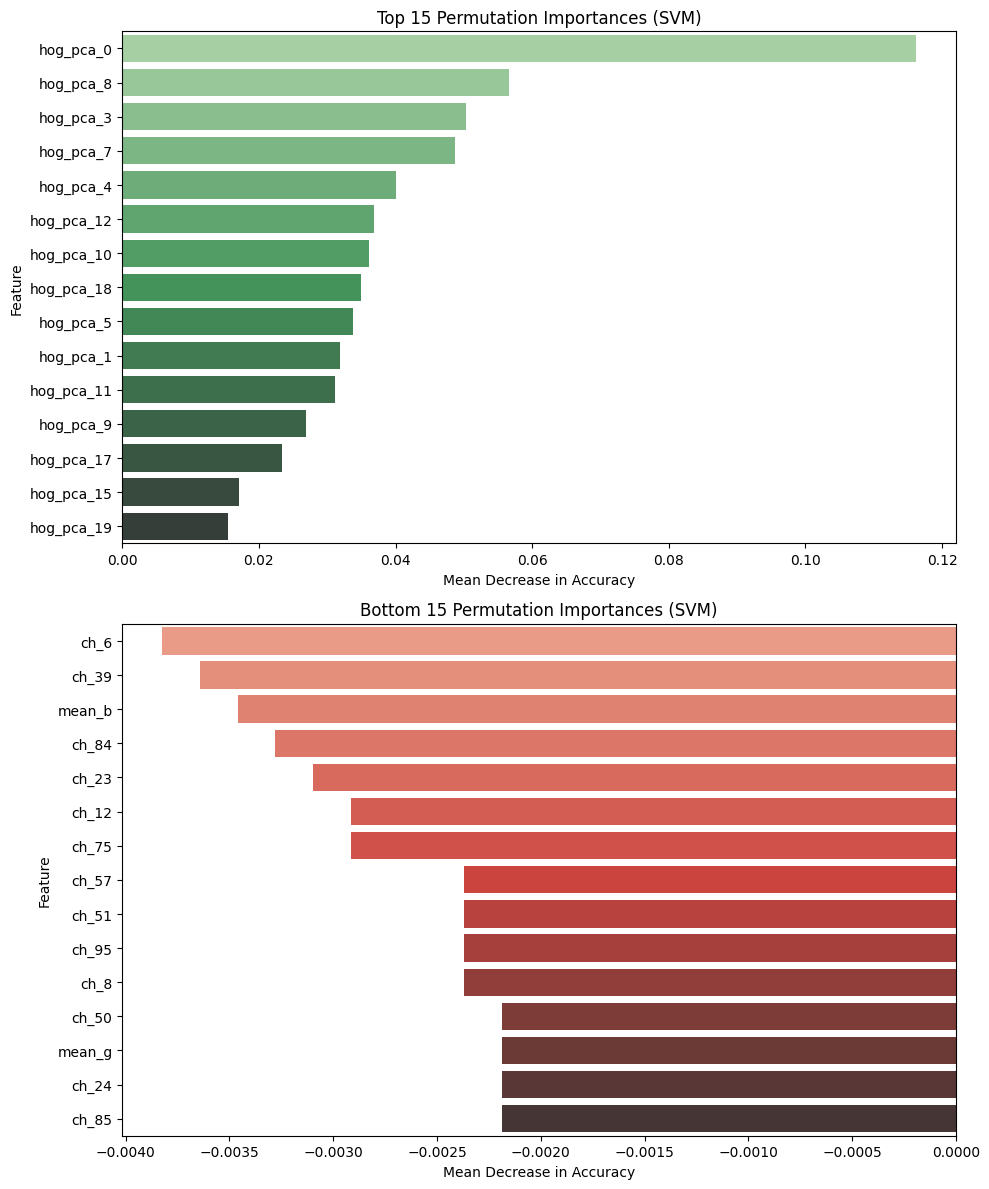

In [ ]:
# show feature importance svm
svm_model = svm.SVC(kernel='rbf', gamma=0.01, C=100)
svm_model.fit(X_scaled_train_all, y_train)

result = permutation_importance(svm_model, X_scaled_val_all, y_val, n_repeats=5, random_state=42)
importance_scores = pd.Series(result.importances_mean, index=feature_names_all)
importance_scores.sort_values(ascending=False)


top_n = 15


top_features = importance_scores.sort_values(ascending=False).head(top_n)
bottom_features = importance_scores.sort_values(ascending=True).head(top_n)


fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# Top features
sns.barplot(x=top_features.values, y=top_features.index, palette="Greens_d", ax=axes[0])
axes[0].set_title(f"Top {top_n} Permutation Importances (SVM)")
axes[0].set_xlabel("Mean Decrease in Accuracy")
axes[0].set_ylabel("Feature")

# Bottom features
sns.barplot(x=bottom_features.values, y=bottom_features.index, palette="Reds_d", ax=axes[1])
axes[1].set_title(f"Bottom {top_n} Permutation Importances (SVM)")
axes[1].set_xlabel("Mean Decrease in Accuracy")
axes[1].set_ylabel("Feature")

plt.tight_layout()
plt.show()


In [ ]:
# HELPER FUNCTIONS FOR FEATURE EXTRACTION
def load_image(path):
    img = cv2.imread(path)        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
    return img_rgb


def preprocess_image(img):
    img_resized = cv2.resize(img, IMG_SIZE)
    blurred = cv2.GaussianBlur(img_resized, (7, 7), 0)
    gray = cv2.cvtColor(blurred, cv2.COLOR_RGB2GRAY)
    equalized = cv2.equalizeHist(gray)
    return equalized

def extract_hog_features(img, orientations=9, pixels_per_cell=(8,8), cells_per_block=(2, 2)):
    hog_features = hog(img, orientations=orientations, pixels_per_cell=pixels_per_cell,
                       cells_per_block=cells_per_block, block_norm='L2-Hys', feature_vector=True)
    return hog_features

def extract_variance_features(image):
    # --- Pixel Intensity Variance ---
    pixel_var = np.var(image)
    # --- LBP Texture Variance ---
    lbp = local_binary_pattern(image, P=8, R=1, method='uniform')  # Radius 1, 8 points
    lbp_var = np.var(lbp)

    return pixel_var, lbp_var

def blur_score(image):
    return cv2.Laplacian(image, cv2.CV_64F).var()

def extract_hsv_stats(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)
    return [
        np.mean(h), np.std(h),
        np.mean(s), np.std(s),
        np.mean(v), np.std(v), 
    ]
    
def hsv_histogram(image, bins=64):
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    h_hist = cv2.calcHist([hsv], [0], None, [bins], [0,180])
    s_hist = cv2.calcHist([hsv], [1], None, [bins], [0,256])
    v_hist = cv2.calcHist([hsv], [2], None, [bins], [0,256])
    hist = np.concatenate([h_hist.flatten(), s_hist.flatten(), v_hist.flatten()])
    hist = hist / hist.sum()
    return hist


def brightness_contrast(image):
    brightness = np.mean(image)
    contrast = np.std(image)
    return brightness, contrast

In [ ]:
# Extract features using helper function
IMG_SIZE = (64, 64)
train_images = [load_image(p) for p in train_metadata['image_path']]
processed_train_images = [preprocess_image(img) for img in train_images]

pixel_vars = []
lbp_vars = []
blur_scores = [] 
brightness = []
contrast = []

for img in processed_train_images:
    pv, lbpv = extract_variance_features(img)
    blur = blur_score(img)
    b, c = brightness_contrast(img)
    
    pixel_vars.append(pv)
    lbp_vars.append(lbpv)
    blur_scores.append(blur)
    brightness.append(b) 
    contrast.append(c) 
    
# Convert to arrays and reshape
train_pixel_vars = np.array(pixel_vars).reshape(-1, 1)
train_lbp_vars = np.array(lbp_vars).reshape(-1, 1)
train_blur_scores = np.array(blur_scores).reshape(-1, 1) 
train_brightness = np.array(brightness).reshape(-1, 1)  
train_contrast = np.array(contrast).reshape(-1, 1)

train_hog_feats = np.array([extract_hog_features(img) for img in processed_train_images])

train_hsv_stats = np.array([extract_hsv_stats(img) for img in train_images])
train_hsv_ch = [hsv_histogram(img) for img in train_images]

### Try HOG features only

In [367]:
X_hog = train_hog_pca.filter(like='hog_pca_')
y = train_metadata["ClassId"].values
    
X_train_trial, X_val_trial, y_train, y_val = train_test_split(X_hog, y, test_size=0.2, random_state=89, stratify=y)

scaler_all = StandardScaler()
X_train_scaled_trial = scaler_all.fit_transform(X_train_trial)
X_val_scaled_trial = scaler_all.transform(X_val_trial)

In [358]:
rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)
rf_model.fit(X_train_scaled_trial, y_train)

train_acc = rf_model.score(X_train_scaled_trial, y_train)
val_acc = rf_model.score(X_val_scaled_trial, y_val)
cv_acc = cross_val_score(rf_model, X_train_scaled_trial, y_train, cv=5).mean()


print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Cross-Validation Accuracy (CV=5): {cv_acc:.4f}")

Training Accuracy: 1.0000
Validation Accuracy: 0.7650
Cross-Validation Accuracy (CV=5): 0.7399


In [356]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1]
}

grid = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5)
grid.fit(X_train_scaled_trial, y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-val accuracy:", grid.best_score_)

Best parameters: {'C': 10, 'gamma': 0.001}
Best cross-val accuracy: 0.8867881548974943


In [368]:
svm_model = svm.SVC(kernel='rbf', gamma=0.001, C=10)
svm_model.fit(X_train_scaled_trial, y_train)

train_acc = svm_model.score(X_train_scaled_trial, y_train)
val_acc = svm_model.score(X_val_scaled_trial, y_val)
cv_acc = cross_val_score(svm_model, X_train_scaled_trial, y_train, cv=5).mean()


print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Cross-Validation Accuracy (CV=5): {cv_acc:.4f}")

Training Accuracy: 0.7513
Validation Accuracy: 0.7332
Cross-Validation Accuracy (CV=5): 0.7137


### Test with Recomputed HOG

In [600]:
y = train_metadata["ClassId"].values
X_train_trial, X_val_trial, y_train, y_val = train_test_split(train_hog_feats, y, test_size=0.2, random_state=89, stratify=y)

scaler_all = StandardScaler()
X_train_scaled_trial = scaler_all.fit_transform(X_train_trial)
X_val_scaled_trial = scaler_all.transform(X_val_trial)

In [349]:
rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)
rf_model.fit(X_train_scaled_trial, y_train)

train_acc = rf_model.score(X_train_scaled_trial, y_train)
val_acc = rf_model.score(X_val_scaled_trial, y_val)
cv_acc = cross_val_score(rf_model, X_train_scaled_trial, y_train, cv=5).mean()


print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Cross-Validation Accuracy (CV=5): {cv_acc:.4f}")

Training Accuracy: 1.0000
Validation Accuracy: 0.9517
Cross-Validation Accuracy (CV=5): 0.9433


In [364]:
svm_model = svm.SVC(kernel='rbf', gamma=0.001, C=10)
svm_model.fit(X_train_scaled_trial, y_train)

train_acc = svm_model.score(X_train_scaled_trial, y_train)
val_acc = svm_model.score(X_val_scaled_trial, y_val)
cv_acc = cross_val_score(svm_model, X_train_scaled_trial, y_train, cv=5).mean()


print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Cross-Validation Accuracy (CV=5): {cv_acc:.4f}")

Training Accuracy: 1.0000
Validation Accuracy: 0.9044
Cross-Validation Accuracy (CV=5): 0.8868


### TEST PCA EFFECT

In [377]:
# Range of PCA dimensions to test
pca_dims = [20 ,100, 1000]

results = []

y = train_metadata["ClassId"].values

X_train, X_val, y_train, y_val = train_test_split(train_hog_feats, y, test_size=0.2, random_state=89, stratify=y)


for n_components in pca_dims:
    # Apply PCA on HOG features
    pca = PCA(n_components=n_components)
    
    train_hog_pca_feats = pca.fit_transform(X_train)
    val_hog_pca_feats = pca.transform(X_val)
    
    # Scale
    scaler_all = StandardScaler()
    X_train_scaled = scaler_all.fit_transform(train_hog_pca_feats)
    X_val_scaled = scaler_all.transform(val_hog_pca_feats)

    # Train model
    model = RandomForestClassifier(
    n_estimators=250,
    max_depth=None,
    min_samples_split=2,
    random_state=42
    )
    
    model.fit(X_train_scaled, y_train)

    train_acc = model.score(X_train_scaled, y_train)
    val_acc = model.score(X_val_scaled, y_val)
    cv_acc = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()

    results.append((n_components, train_acc, val_acc, cv_acc))
    print(f"PCA: {n_components} → Train: {train_acc:.4f}, Val: {val_acc:.4f}, CV: {cv_acc:.4f}")

PCA: 20 → Train: 1.0000, Val: 0.7423, CV: 0.7182
PCA: 100 → Train: 1.0000, Val: 0.8142, CV: 0.7991
PCA: 1000 → Train: 1.0000, Val: 0.7104, CV: 0.6649


In [ ]:

y = train_metadata["ClassId"].values

# Range of PCA dimensions to test
pca_dims = [80, 100, 150, 200, 225, 250, 300, 350, 400]
results = []

X_train, X_val, y_train, y_val = train_test_split(
    train_hog_feats, y, test_size=0.2, random_state=89, stratify=y
)

for n_components in pca_dims:
    # Apply PCA on HOG features
    pca = PCA(n_components=n_components)
    train_hog_pca_feats = pca.fit_transform(X_train)
    val_hog_pca_feats = pca.transform(X_val)

    # Scale
    scaler_all = StandardScaler()
    X_train_scaled = scaler_all.fit_transform(train_hog_pca_feats)
    X_val_scaled = scaler_all.transform(val_hog_pca_feats)

    # Train model
    model = svm.SVC(kernel='rbf', gamma=0.001, C=10)
    model.fit(X_train_scaled, y_train)

    # Evaluate
    train_acc = model.score(X_train_scaled, y_train)
    val_acc = model.score(X_val_scaled, y_val)
    cv_acc = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()

    results.append((n_components, train_acc, val_acc, cv_acc))
    print(f"PCA: {n_components} → Train: {train_acc:.4f}, Val: {val_acc:.4f}, CV: {cv_acc:.4f}")


PCA: 80 → Train: 0.9688, Val: 0.9062, CV: 0.9046
PCA: 100 → Train: 0.9827, Val: 0.9117, CV: 0.9130
PCA: 150 → Train: 0.9957, Val: 0.9372, CV: 0.9212
PCA: 200 → Train: 0.9989, Val: 0.9435, CV: 0.9210
PCA: 225 → Train: 0.9998, Val: 0.9481, CV: 0.9271
PCA: 250 → Train: 0.9998, Val: 0.9472, CV: 0.9219
PCA: 300 → Train: 1.0000, Val: 0.9435, CV: 0.9241
PCA: 350 → Train: 1.0000, Val: 0.9481, CV: 0.9226
PCA: 400 → Train: 1.0000, Val: 0.9435, CV: 0.9162


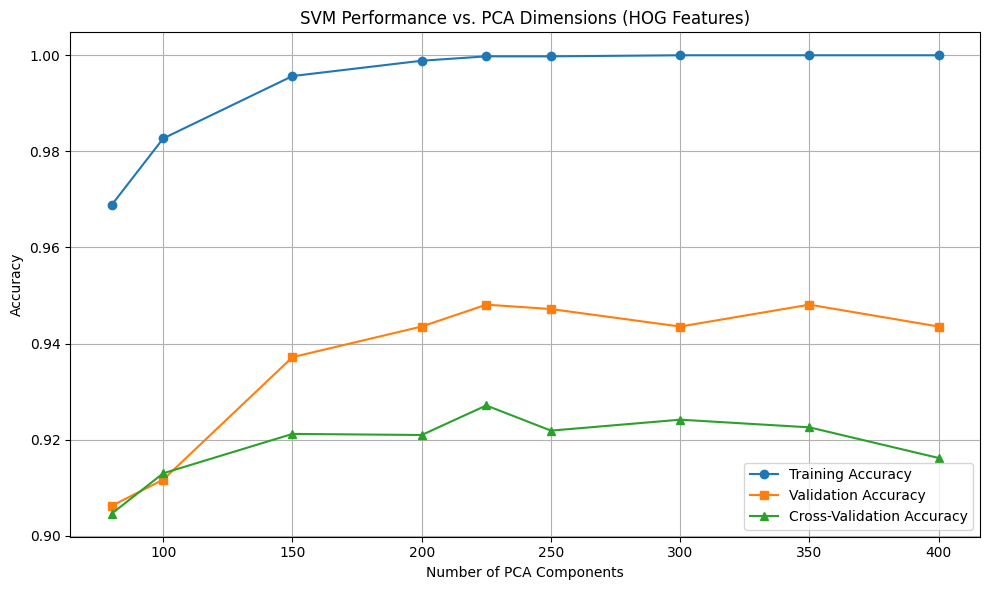

In [ ]:
# Plot results
pca_dims, train_accs, val_accs, cv_accs = zip(*results)

plt.figure(figsize=(10, 6))
plt.plot(pca_dims, train_accs, marker='o', label='Training Accuracy')
plt.plot(pca_dims, val_accs, marker='s', label='Validation Accuracy')
plt.plot(pca_dims, cv_accs, marker='^', label='Cross-Validation Accuracy')

plt.title("SVM Performance vs. PCA Dimensions (HOG Features)")
plt.xlabel("Number of PCA Components")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Recomputed HOG + Mean RGB/HSV

### RF

In [ ]:
#  Merge train data with the mean rgb file only
train_df_meanrgb = train_metadata.merge(train_meanrgb, on="image_path")
X_train_meanrgb = train_df_meanrgb.drop(columns=["ClassId", "id", "image_path"], errors="ignore").values
X_train_meanrgb.shape


(5488, 4)

In [ ]:
Xedge_density = train_df_meanrgb .drop(columns=["ClassId", "id", "image_path", "mean_r", "mean_g", "mean_b"], errors="ignore").values
X_train_meanhsv = np.hstack([Xedge_density, train_hsv_stats])

In [ ]:
X_trial = np.hstack([train_hog_feats, X_train_meanrgb ])
y = train_metadata["ClassId"].values
    
X_train_trial, X_val_trial, y_train, y_val = train_test_split(X_trial, y, test_size=0.2, random_state=89, stratify=y)

scaler_all = StandardScaler()
X_train_scaled_trial = scaler_all.fit_transform(X_train_trial)
X_val_scaled_trial = scaler_all.transform(X_val_trial)

rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)
rf_model.fit(X_train_scaled_trial, y_train)

train_acc = rf_model.score(X_train_scaled_trial, y_train)
val_acc = rf_model.score(X_val_scaled_trial, y_val)
cv_acc = cross_val_score(rf_model, X_train_scaled_trial, y_train, cv=5).mean()


print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Cross-Validation Accuracy (CV=5): {cv_acc:.4f}")

Training Accuracy: 1.0000
Validation Accuracy: 0.9536
Cross-Validation Accuracy (CV=5): 0.9437


In [385]:
X_trial = np.hstack([train_hog_feats, X_train_meanhsv])
y = train_metadata["ClassId"].values
    
X_train_trial, X_val_trial, y_train, y_val = train_test_split(X_trial, y, test_size=0.2, random_state=89, stratify=y)

scaler_all = StandardScaler()
X_train_scaled_trial = scaler_all.fit_transform(X_train_trial)
X_val_scaled_trial = scaler_all.transform(X_val_trial)

rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)
rf_model.fit(X_train_scaled_trial, y_train)

train_acc = rf_model.score(X_train_scaled_trial, y_train)
val_acc = rf_model.score(X_val_scaled_trial, y_val)
cv_acc = cross_val_score(rf_model, X_train_scaled_trial, y_train, cv=5).mean()


print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Cross-Validation Accuracy (CV=5): {cv_acc:.4f}")

Training Accuracy: 1.0000
Validation Accuracy: 0.9454
Cross-Validation Accuracy (CV=5): 0.9462


Results: Mean HSV used since CV accuracy higher


### SVM

In [386]:
pca = PCA(n_components=225)
hog_pca_feats = pca.fit_transform(train_hog_feats)


X_trial = np.hstack([hog_pca_feats, X_train_meanrgb])
y = train_metadata["ClassId"].values
    
X_train_trial, X_val_trial, y_train, y_val = train_test_split(X_trial, y, test_size=0.2, random_state=89, stratify=y)

scaler_all = StandardScaler()
X_train_scaled_trial = scaler_all.fit_transform(X_train_trial)
X_val_scaled_trial = scaler_all.transform(X_val_trial)

svm_model = svm.SVC(kernel='rbf', gamma=0.001, C=10)
svm_model.fit(X_train_scaled_trial, y_train)

train_acc = svm_model.score(X_train_scaled_trial, y_train)
val_acc = svm_model.score(X_val_scaled_trial, y_val)
cv_acc = cross_val_score(svm_model, X_train_scaled_trial, y_train, cv=5).mean()


print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Cross-Validation Accuracy (CV=5): {cv_acc:.4f}")

Training Accuracy: 0.9998
Validation Accuracy: 0.9435
Cross-Validation Accuracy (CV=5): 0.9269


In [387]:
pca = PCA(n_components=225)
hog_pca_feats = pca.fit_transform(train_hog_feats)


X_trial = np.hstack([hog_pca_feats, X_train_meanhsv])
y = train_metadata["ClassId"].values
    
X_train_trial, X_val_trial, y_train, y_val = train_test_split(X_trial, y, test_size=0.2, random_state=89, stratify=y)

scaler_all = StandardScaler()
X_train_scaled_trial = scaler_all.fit_transform(X_train_trial)
X_val_scaled_trial = scaler_all.transform(X_val_trial)

svm_model = svm.SVC(kernel='rbf', gamma=0.001, C=10)
svm_model.fit(X_train_scaled_trial, y_train)

train_acc = svm_model.score(X_train_scaled_trial, y_train)
val_acc = svm_model.score(X_val_scaled_trial, y_val)
cv_acc = cross_val_score(svm_model, X_train_scaled_trial, y_train, cv=5).mean()


print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Cross-Validation Accuracy (CV=5): {cv_acc:.4f}")

Training Accuracy: 0.9998
Validation Accuracy: 0.9444
Cross-Validation Accuracy (CV=5): 0.9280


Results: use mean hsv

### HOG + Mean HSV + COLOUR HISTOGRAM

In [609]:
X_trial = np.hstack([train_hog_feats, X_train_meanhsv, train_hsv_ch])
y = train_metadata["ClassId"].values
    
X_train_trial, X_val_trial, y_train, y_val,  idx_train, idx_val = train_test_split(X_trial, y, np.arange(len(X_trial)), test_size=0.2, random_state=89, stratify=y)

scaler_all = StandardScaler()
X_train_scaled_trial = scaler_all.fit_transform(X_train_trial)
X_val_scaled_trial = scaler_all.transform(X_val_trial)

rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=None,
    min_samples_split=3,
    min_samples_leaf = 2,
    random_state=42, class_weight = 'balanced'
)
rf_model.fit(X_train_scaled_trial, y_train)

train_acc = rf_model.score(X_train_scaled_trial, y_train)
val_acc = rf_model.score(X_val_scaled_trial, y_val)
cv_acc = cross_val_score(rf_model, X_train_scaled_trial, y_train, cv=5).mean()


print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Cross-Validation Accuracy (CV=5): {cv_acc:.4f}")

Training Accuracy: 1.0000
Validation Accuracy: 0.9599
Cross-Validation Accuracy (CV=5): 0.9474


Number of misclassified samples: 44


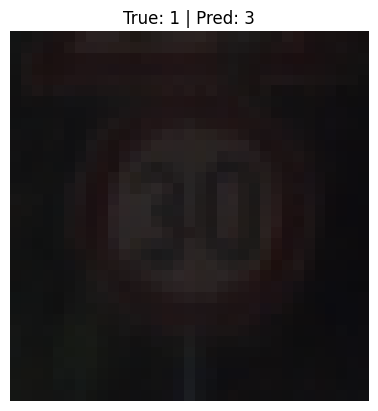

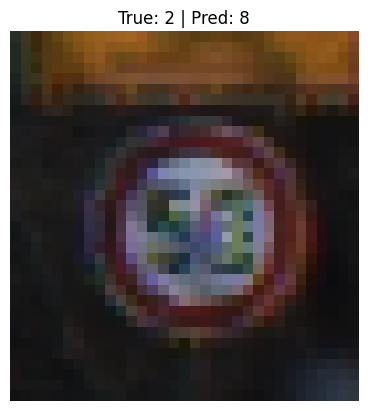

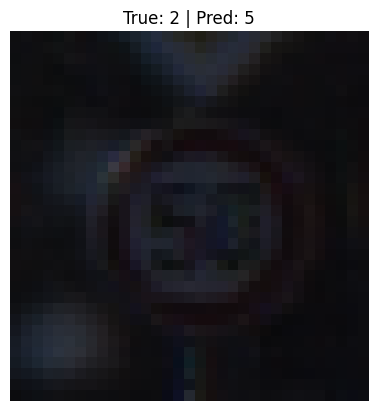

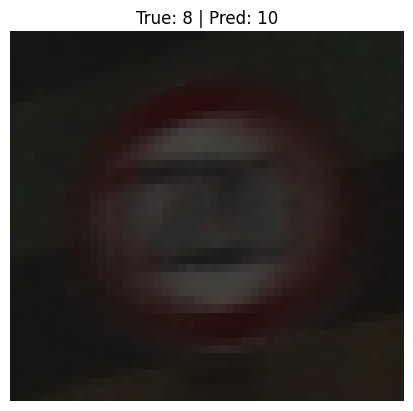

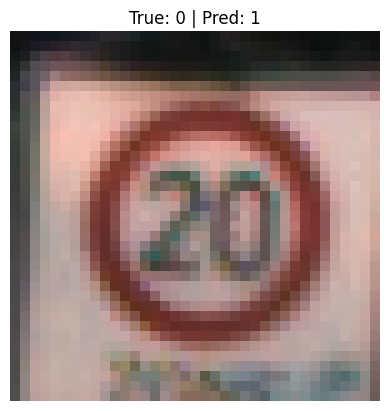

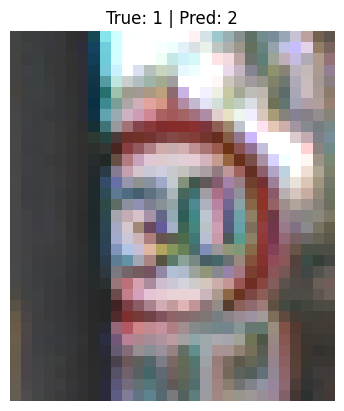

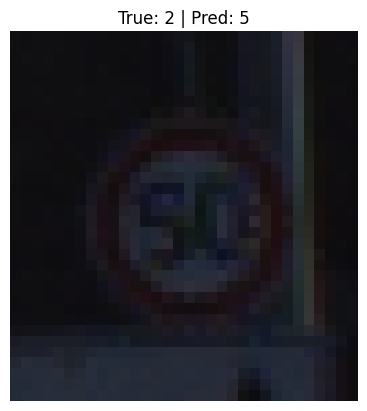

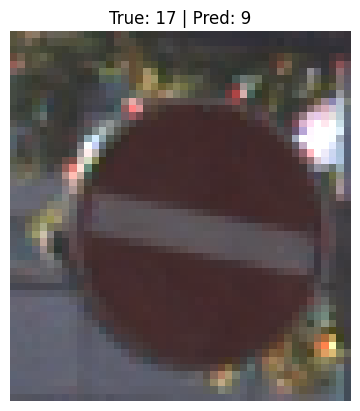

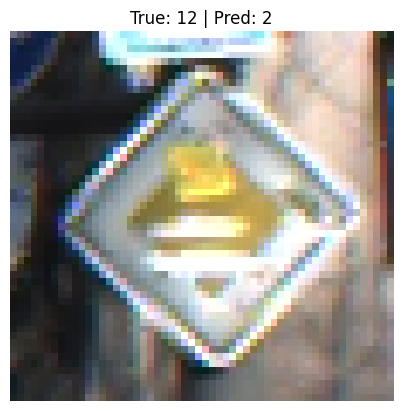

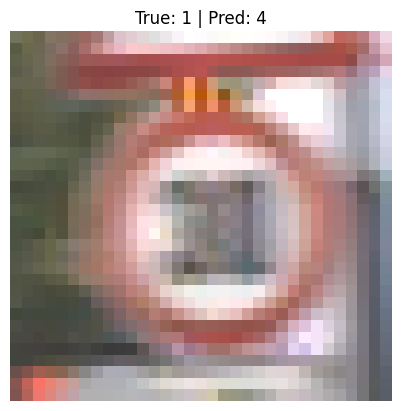

In [ ]:
y_pred= rf_model.predict(X_val_scaled_trial)
misclassified_idx = np.where(y_pred != y_val)[0]

num_misclassified = misclassified_idx.shape[0]
print("Number of misclassified samples:", num_misclassified)
misclassified_orig_idx = idx_val[misclassified_idx]

misclassified_paths = train_metadata.loc[misclassified_orig_idx, "image_path"].values
true_labels = y_val[misclassified_idx]
pred_labels = y_pred[misclassified_idx]

import matplotlib.image as mpimg

for i in range(min(10, len(misclassified_paths))):
    img = mpimg.imread(misclassified_paths[i])
    plt.imshow(img)
    plt.title(f"True: {true_labels[i]} | Pred: {pred_labels[i]}")
    plt.axis("off")
    plt.show()

In [ ]:

# Create pairs of (true, predicted) for all misclassifications
misclass_pairs = list(zip(true_labels, pred_labels))

# Count how often each (true, predicted) pair occurred
pair_counts = Counter(misclass_pairs)

# Convert to DataFrame for easier viewing and sorting
misclass_df = pd.DataFrame(pair_counts.items(), columns=["(True, Pred)", "Count"])
misclass_df = misclass_df.sort_values("Count", ascending=False)

print("Most common misclassifications:")
print(misclass_df)


Most common misclassifications:
   (True, Pred)  Count
1        (2, 8)      3
26       (5, 2)      3
16       (4, 8)      2
2        (2, 5)      2
18     (26, 25)      2
15       (3, 2)      2
7       (12, 2)      2
14       (5, 8)      2
11     (29, 25)      2
24     (18, 25)      1
22       (3, 5)      1
23       (0, 4)      1
25     (11, 25)      1
20     (40, 10)      1
27      (14, 9)      1
28     (18, 13)      1
29       (8, 5)      1
30       (5, 7)      1
31      (38, 7)      1
21     (21, 31)      1
0        (1, 3)      1
19      (5, 10)      1
17     (30, 23)      1
13       (5, 3)      1
12       (1, 5)      1
10     (30, 25)      1
9      (18, 10)      1
8        (1, 4)      1
6       (17, 9)      1
5        (1, 2)      1
4        (0, 1)      1
3       (8, 10)      1
32     (25, 10)      1


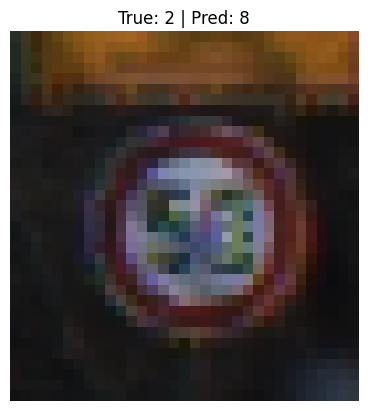

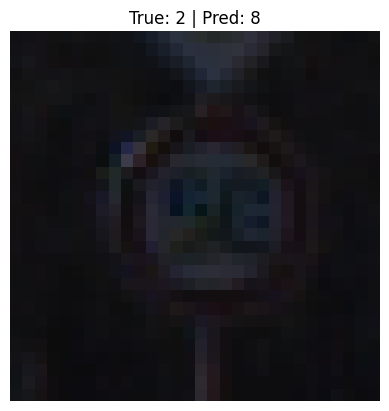

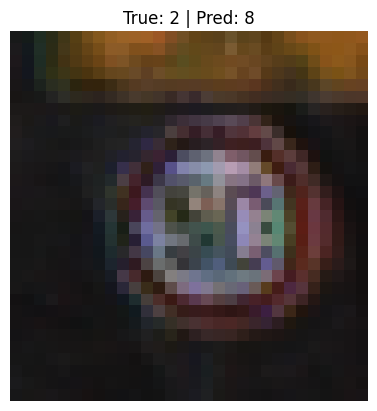

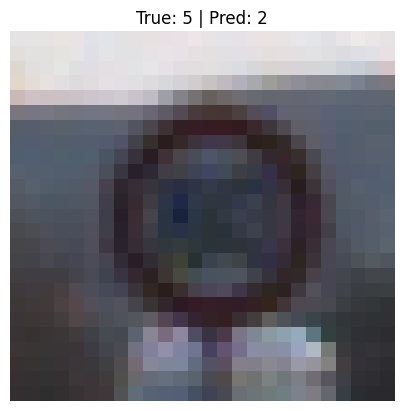

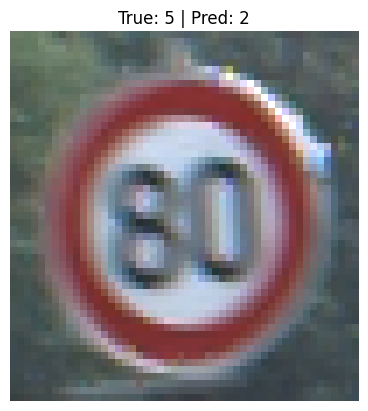

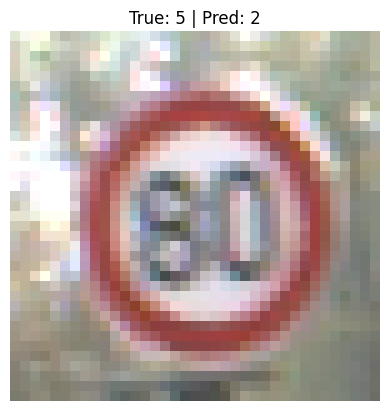

In [ ]:

#  Select pairs that occurred exactly n times
pairs_with_3_misclass = [pair for pair, count in pair_counts.items() if count == 3]

# Find indices of those specific misclassifications
selected_indices = [i for i, pair in enumerate(misclass_pairs) if pair in pairs_with_3_misclass]

# Show images for selected misclassifications
for i in selected_indices:
    img = mpimg.imread(misclassified_paths[i])
    plt.imshow(img)
    plt.title(f"True: {true_labels[i]} | Pred: {pred_labels[i]}")
    plt.axis("off")
    plt.show()


In [470]:
pca = PCA(n_components=225)
hog_pca_feats = pca.fit_transform(train_hog_feats)

X_trial = np.hstack([hog_pca_feats, X_train_meanhsv, train_hsv_ch])
y = train_metadata["ClassId"].values
    
X_train_trial, X_val_trial, y_train, y_val = train_test_split(X_trial, y, test_size=0.2, random_state=89, stratify=y)

scaler_all = StandardScaler()
X_train_scaled_trial = scaler_all.fit_transform(X_train_trial)
X_val_scaled_trial = scaler_all.transform(X_val_trial)

svm_model = svm.SVC(kernel='rbf', gamma=0.001, C=10)
svm_model.fit(X_train_scaled_trial, y_train)

train_acc = svm_model.score(X_train_scaled_trial, y_train)
val_acc = svm_model.score(X_val_scaled_trial, y_val)
cv_acc = cross_val_score(svm_model, X_train_scaled_trial, y_train, cv=5).mean()


print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Cross-Validation Accuracy (CV=5): {cv_acc:.4f}")



Training Accuracy: 1.0000
Validation Accuracy: 0.9408
Cross-Validation Accuracy (CV=5): 0.9200


### Adding Texture Variance

In [621]:
X_trial = np.hstack([train_hog_feats, X_train_meanhsv, train_hsv_ch, train_lbp_vars])
y = train_metadata["ClassId"].values
    
X_train_trial, X_val_trial, y_train, y_val,  idx_train, idx_val = train_test_split(X_trial, y, np.arange(len(X_trial)), test_size=0.2, random_state=89, stratify=y)

scaler_all = StandardScaler()
X_train_scaled_trial = scaler_all.fit_transform(X_train_trial)
X_val_scaled_trial = scaler_all.transform(X_val_trial)

rf_model_lbp = RandomForestClassifier(
    n_estimators=250,
    max_depth=None,
    min_samples_split=3,
    min_samples_leaf = 2,
    random_state=42, class_weight = 'balanced'
)

rf_model_lbp.fit(X_train_scaled_trial, y_train)

train_acc = rf_model_lbp.score(X_train_scaled_trial, y_train)
val_acc = rf_model_lbp.score(X_val_scaled_trial, y_val)
cv_acc = cross_val_score(rf_model_lbp, X_train_scaled_trial, y_train, cv=5).mean()


print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Cross-Validation Accuracy (CV=5): {cv_acc:.4f}")

Training Accuracy: 1.0000
Validation Accuracy: 0.9617
Cross-Validation Accuracy (CV=5): 0.9476


Number of misclassified samples: 42


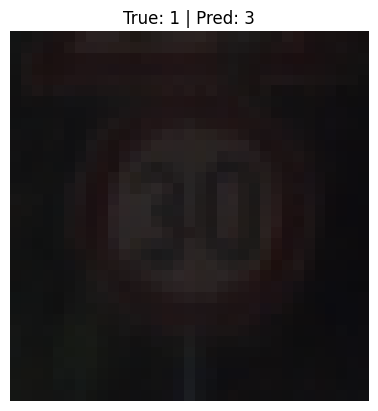

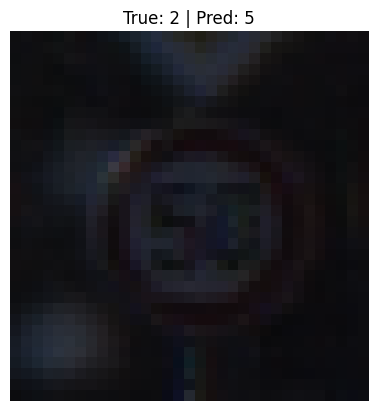

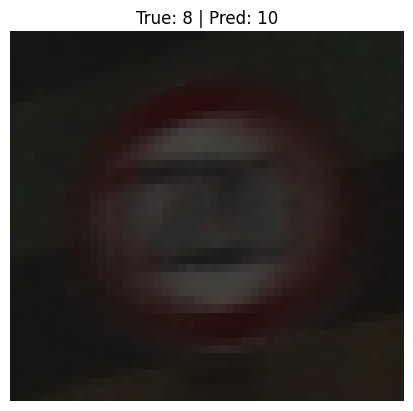

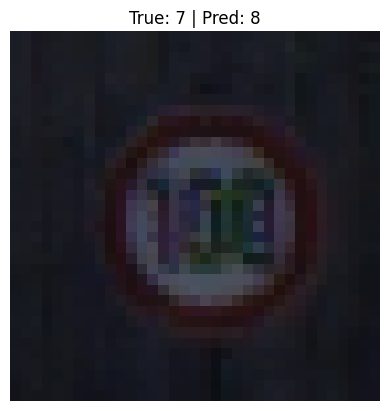

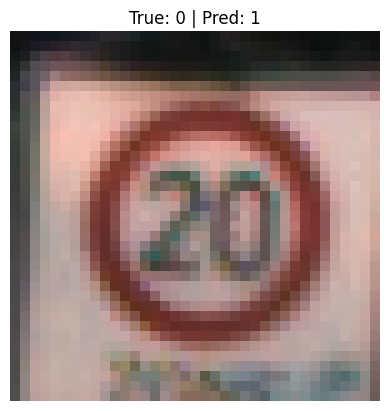

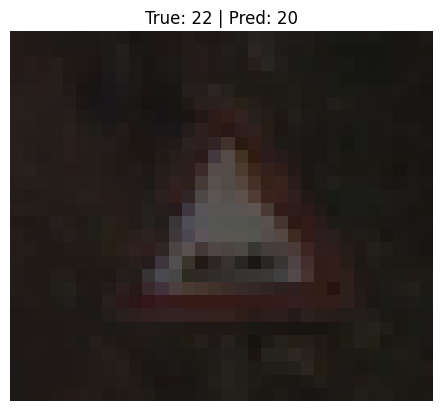

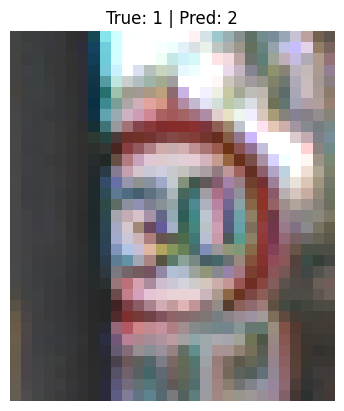

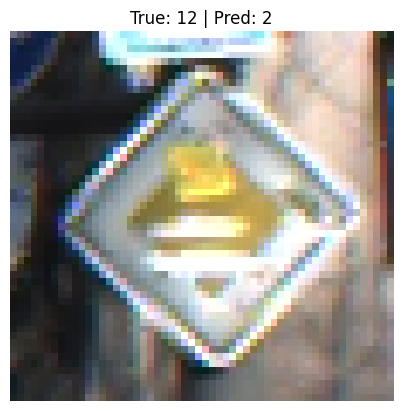

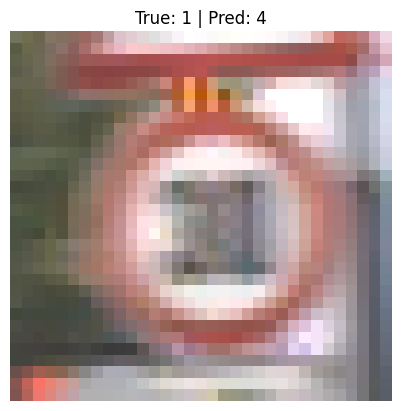

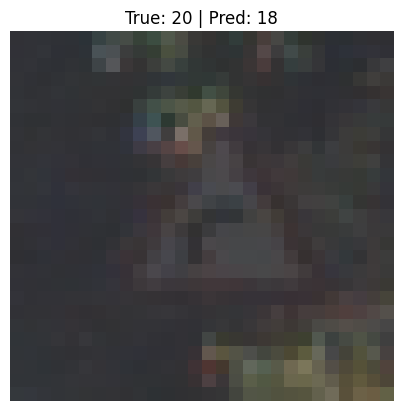

In [ ]:
# For analysing misclassified classes
y_pred_rf_lbp = rf_model_lbp.predict(X_val_scaled_trial)
misclassified_idx_lbp = np.where(y_pred_rf_lbp != y_val)[0]

num_misclassified_lbp = misclassified_idx_lbp.shape[0]
print("Number of misclassified samples:", num_misclassified_lbp)
misclassified_orig_idx_lbp = idx_val[misclassified_idx_lbp]

misclassified_paths_lbp = train_metadata.loc[misclassified_orig_idx_lbp, "image_path"].values
true_labels_lbp = y_val[misclassified_idx_lbp]
pred_labels_lbp = y_pred_rf_lbp[misclassified_idx_lbp]

import matplotlib.image as mpimg

for i in range(min(10, len(misclassified_paths_lbp))):
    img = mpimg.imread(misclassified_paths_lbp[i])
    plt.imshow(img)
    plt.title(f"True: {true_labels_lbp[i]} | Pred: {pred_labels_lbp[i]}")
    plt.axis("off")
    plt.show()

In [ ]:

# Analyse common misclassification
misclass_pairs_lbp = list(zip(true_labels_lbp, pred_labels_lbp))

# Count how often each (true, predicted) pair occurred
pair_counts_lbp = Counter(misclass_pairs_lbp)
misclass_df_lbp = pd.DataFrame(pair_counts_lbp.items(), columns=["(True, Pred)", "Count"])
misclass_df_lbp = misclass_df_lbp.sort_values("Count", ascending=False)

print("Most common misclassifications:")
print(misclass_df_lbp)


Most common misclassifications:
   (True, Pred)  Count
17       (4, 8)      2
1        (2, 5)      2
16       (3, 5)      2
6        (1, 2)      2
7       (12, 2)      2
14       (5, 8)      2
24       (5, 2)      2
26     (18, 25)      1
22      (5, 10)      1
23      (40, 7)      1
25       (0, 2)      1
27     (19, 31)      1
20       (2, 8)      1
28     (11, 25)      1
29      (14, 9)      1
30     (42, 15)      1
31     (18, 38)      1
32       (8, 5)      1
33       (5, 7)      1
21     (23, 31)      1
0        (1, 3)      1
19       (8, 4)      1
18       (4, 2)      1
15     (26, 25)      1
13     (38, 12)      1
12     (29, 25)      1
11     (30, 40)      1
10     (18, 10)      1
9      (20, 18)      1
8        (1, 4)      1
5      (22, 20)      1
4        (0, 1)      1
3        (7, 8)      1
2       (8, 10)      1
34       (3, 2)      1


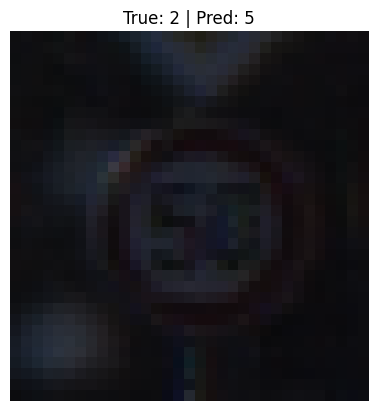

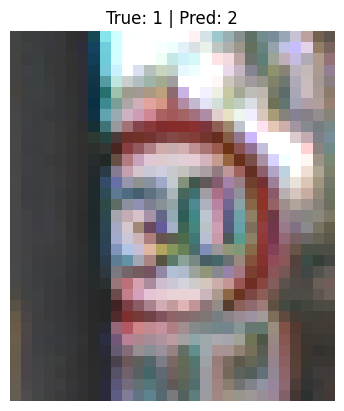

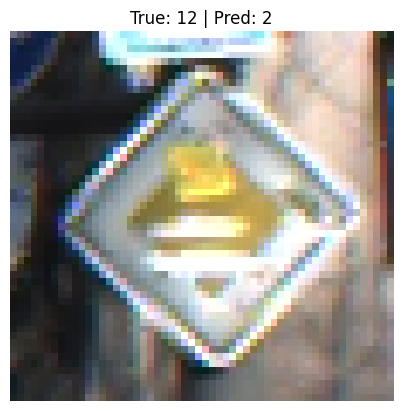

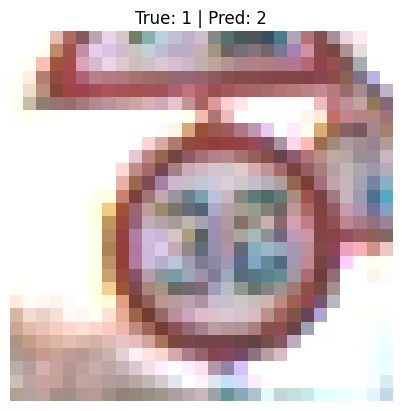

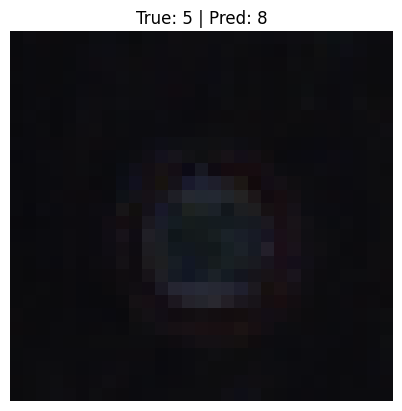

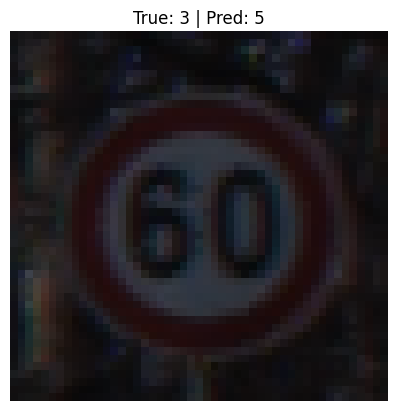

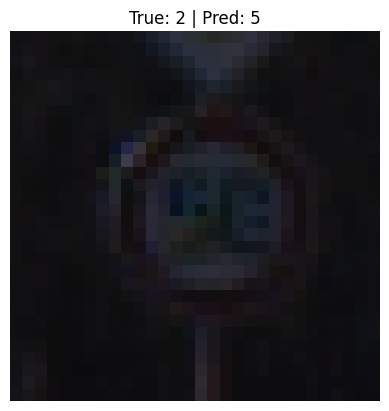

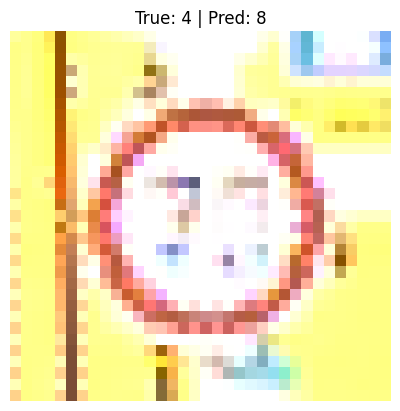

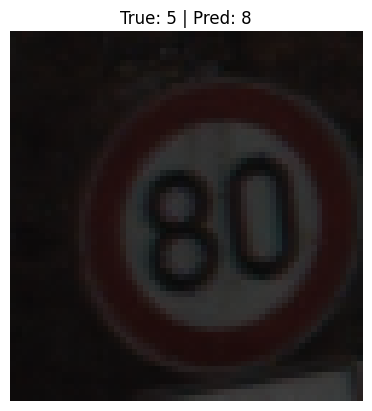

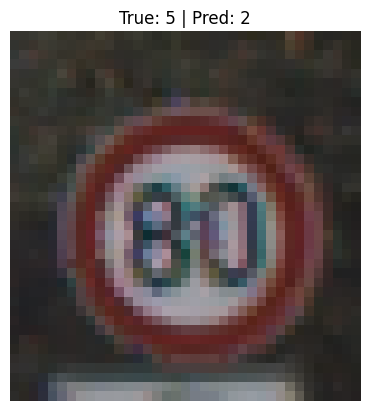

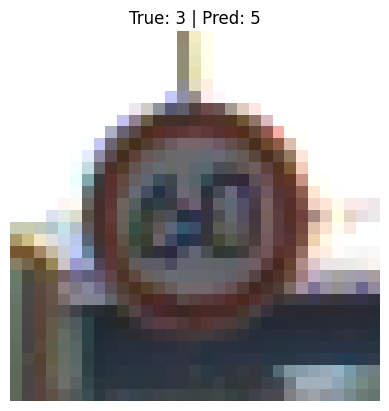

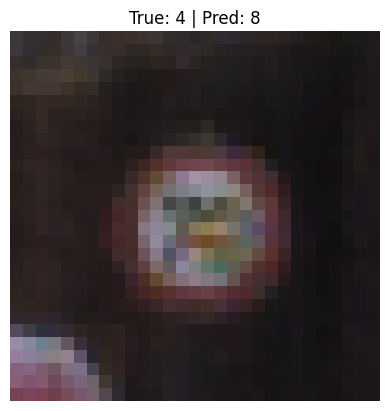

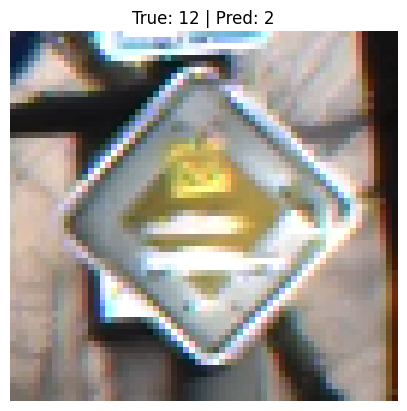

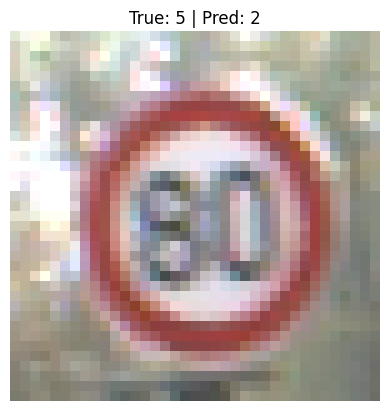

In [ ]:
# VISUALIZE THE TOP MISCLASSIFIED

# Select pairs that occurred exactly 3 times
pairs_with_3_misclass_lbp = [pair for pair, count in pair_counts_lbp.items() if count == 2]

selected_indices_lbp = [i for i, pair in enumerate(misclass_pairs_lbp) if pair in pairs_with_3_misclass_lbp]
for i in selected_indices_lbp:
    img = mpimg.imread(misclassified_paths_lbp[i])
    plt.imshow(img)
    plt.title(f"True: {true_labels_lbp[i]} | Pred: {pred_labels_lbp[i]}")
    plt.axis("off")
    plt.show()


### TEST PIXEL VARIANCE

In [626]:
X_trial_pixel = np.hstack([train_hog_feats, X_train_meanhsv, train_hsv_ch, train_lbp_vars, train_pixel_vars])
y = train_metadata["ClassId"].values
    
X_train_trial, X_val_trial, y_train, y_val = train_test_split(X_trial_pixel, y, test_size=0.2, random_state=89, stratify=y)

scaler_all = StandardScaler()
X_train_scaled_trial = scaler_all.fit_transform(X_train_trial)
X_val_scaled_trial = scaler_all.transform(X_val_trial)

rf_model_pixel = RandomForestClassifier(
    n_estimators=250,
    max_depth=None,
    min_samples_split=3,
    min_samples_leaf = 2,
    random_state=42, class_weight = 'balanced'
)
rf_model_pixel.fit(X_train_scaled_trial, y_train)

train_acc = rf_model_pixel.score(X_train_scaled_trial, y_train)
val_acc = rf_model_pixel.score(X_val_scaled_trial, y_val)
cv_acc = cross_val_score(rf_model_pixel, X_train_scaled_trial, y_train, cv=5).mean()


print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Cross-Validation Accuracy (CV=5): {cv_acc:.4f}")

Training Accuracy: 1.0000
Validation Accuracy: 0.9599
Cross-Validation Accuracy (CV=5): 0.9474


In [ ]:
pca = PCA(n_components=225)
hog_pca_feats = pca.fit_transform(train_hog_feats)

X_trial = np.hstack([hog_pca_feats, X_train_meanhsv, train_hsv_ch, train_lbp_vars])
y = train_metadata["ClassId"].values
    
X_train_trial, X_val_trial, y_train, y_val = train_test_split(X_trial, y, test_size=0.2, random_state=89, stratify=y)

scaler_all = StandardScaler()
X_train_scaled_trial = scaler_all.fit_transform(X_train_trial)
X_val_scaled_trial = scaler_all.transform(X_val_trial)

svm_model = svm.SVC(kernel='rbf', gamma=0.001, C=10)
svm_model.fit(X_train_scaled_trial, y_train)

train_acc = svm_model.score(X_train_scaled_trial, y_train)
val_acc = svm_model.score(X_val_scaled_trial, y_val)
cv_acc = cross_val_score(svm_model, X_train_scaled_trial, y_train, cv=5).mean()


print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Cross-Validation Accuracy (CV=5): {cv_acc:.4f}")

Training Accuracy: 1.0000
Validation Accuracy: 0.9417
Cross-Validation Accuracy (CV=5): 0.9230


#### Try adding Brightness, Contrast AND Blur Score

In [628]:
X_trial = np.hstack([train_hog_feats, X_train_meanhsv, train_hsv_ch, train_lbp_vars, train_pixel_vars, train_brightness, train_contrast, train_blur_scores])
y = train_metadata["ClassId"].values
    
X_train_trial, X_val_trial, y_train, y_val = train_test_split(X_trial, y, test_size=0.2, random_state=89, stratify=y)

scaler_all = StandardScaler()
X_train_scaled_trial = scaler_all.fit_transform(X_train_trial)
X_val_scaled_trial = scaler_all.transform(X_val_trial)

rf_model_all = RandomForestClassifier(
    n_estimators=250,
    max_depth=None,
    min_samples_split=3,
    min_samples_leaf = 2,
    random_state=42, class_weight = 'balanced'
)
rf_model_all.fit(X_train_scaled_trial, y_train)

train_acc = rf_model_all.score(X_train_scaled_trial, y_train)
val_acc = rf_model_all.score(X_val_scaled_trial, y_val)
cv_acc = cross_val_score(rf_model_all, X_train_scaled_trial, y_train, cv=5).mean()


print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Cross-Validation Accuracy (CV=5): {cv_acc:.4f}")

Training Accuracy: 1.0000
Validation Accuracy: 0.9581
Cross-Validation Accuracy (CV=5): 0.9481


Note: not added

### Final Feature Set
- hog_pca_feats, X_train_meanhsv, train_hsv_ch, train_lbp_vars


## Finetune

### Random Forest

In [15]:
X_trial = np.hstack([train_hog_feats, X_train_meanhsv, train_hsv_ch, train_lbp_vars])
y = train_metadata["ClassId"].values
    
X_train_trial, X_val_trial, y_train, y_val,  idx_train, idx_val = train_test_split(X_trial, y, np.arange(len(X_trial)), test_size=0.2, random_state=89, stratify=y)

scaler_all = StandardScaler()
X_train_scaled_trial = scaler_all.fit_transform(X_train_trial)
X_val_scaled_trial = scaler_all.transform(X_val_trial)


In [ ]:

param_grid = {
    'max_depth': [10, 20, 30, 40],
    'min_samples_split': [3, 5, 7],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight = 'balanced') 
grid_search = GridSearchCV(rf, param_grid, cv=5, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train_scaled_trial , y_train)

print("Best Params:", grid_search.best_params_)
print("Validation Accuracy:", grid_search.score(X_val_scaled_trial , y_val))

Best Params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 3}
Validation Accuracy: 0.9562841530054644


In [655]:

param_grid = {
    'max_depth': [10, 20, 30, 40],
    'min_samples_split': [3, 5, 7],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight = 'balanced') 
grid_search = GridSearchCV(rf, param_grid, cv=5, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train_scaled_trial , y_train)

print("Best Params:", grid_search.best_params_)
print("Validation Accuracy:", grid_search.score(X_val_scaled_trial , y_val))

Best Params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 3}
Validation Accuracy: 0.9444444444444444


### RF Performance on Validation Set

In [ ]:

Xtrain_rf = np.hstack([train_hog_feats, X_train_meanhsv, train_hsv_ch, train_lbp_vars])
y = train_metadata["ClassId"].values
    
X_train_rf, X_val_rf, y_train, y_val,  idx_train_rf, idx_val_rf = train_test_split(Xtrain_rf, y, np.arange(len(Xtrain_rf)), test_size=0.2, random_state=89, stratify=y)

scaler_all = StandardScaler()
X_train_scaled_rf = scaler_all.fit_transform(X_train_rf)
X_val_scaled_rf = scaler_all.transform(X_val_rf)

rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=None,
    min_samples_split=3,
    min_samples_leaf = 2,
    random_state=42, class_weight = 'balanced'
)
rf_model.fit(X_train_scaled_rf, y_train)

train_acc = rf_model.score(X_train_scaled_rf, y_train)
val_acc = rf_model.score(X_val_scaled_rf, y_val)
cv_acc = cross_val_score(rf_model, X_train_scaled_rf, y_train, cv=5).mean()


print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Cross-Validation Accuracy (CV=5): {cv_acc:.4f}")

Training Accuracy: 1.0000
Validation Accuracy: 0.9617
Cross-Validation Accuracy (CV=5): 0.9476


In [17]:
from sklearn.metrics import classification_report

y_pred_rf= rf_model.predict(X_val_scaled_rf)
print(classification_report(y_val, y_pred_rf, digits=4))

              precision    recall  f1-score   support

           0     1.0000    0.6667    0.8000         6
           1     0.9831    0.9355    0.9587        62
           2     0.8696    0.9524    0.9091        63
           3     0.9730    0.9231    0.9474        39
           4     0.9630    0.9455    0.9541        55
           5     0.9020    0.8846    0.8932        52
           6     1.0000    1.0000    1.0000        12
           7     0.9512    0.9750    0.9630        40
           8     0.8571    0.9231    0.8889        39
           9     0.9762    1.0000    0.9880        41
          10     0.9492    1.0000    0.9739        56
          11     1.0000    0.9730    0.9863        37
          12     0.9828    0.9661    0.9744        59
          13     1.0000    1.0000    1.0000        60
          14     1.0000    0.9545    0.9767        22
          15     0.9474    1.0000    0.9730        18
          16     1.0000    1.0000    1.0000        12
          17     1.0000    

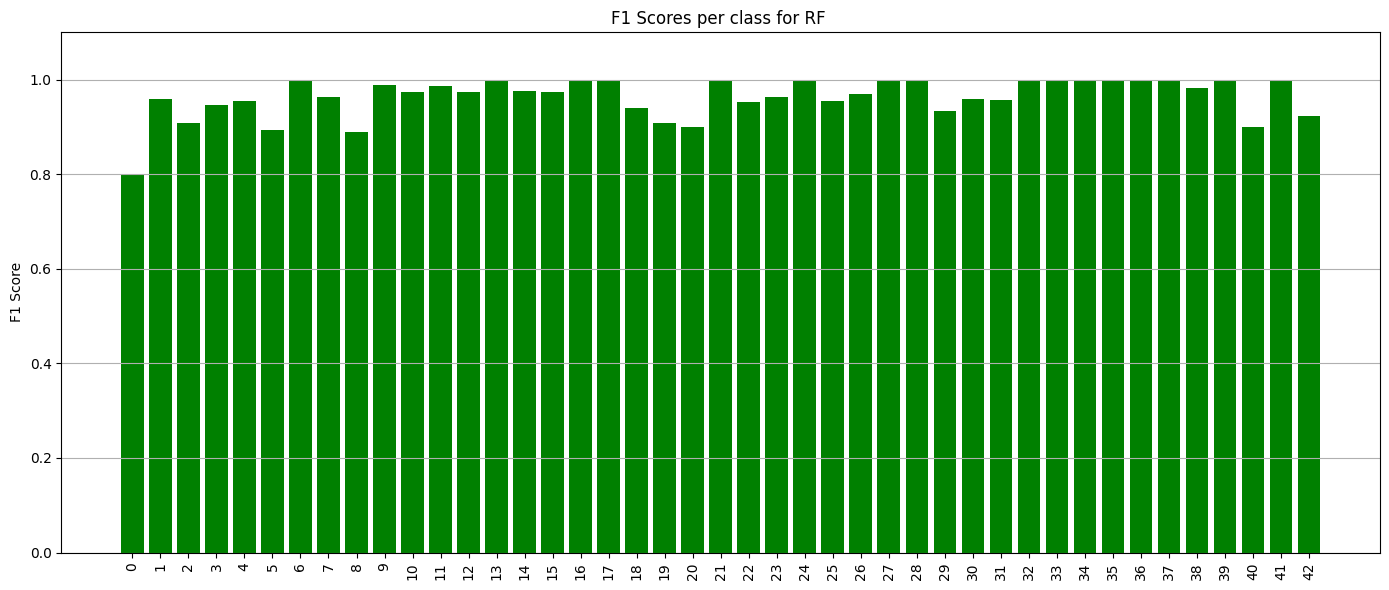

In [24]:
class_names = [str(i) for i in range(43)]
f1_scores = f1_score(y_val, y_pred_rf, average=None)

plt.figure(figsize=(14,6))
plt.bar(range(len(class_names)), f1_scores, color='green')
plt.xticks(range(len(class_names)), class_names, rotation=90)
plt.ylabel("F1 Score")
plt.title("F1 Scores per class for RF ")
plt.ylim(0, 1.1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# FOR ANALYSING PURPOSES
misclassified_idx_rf = np.where(y_pred_rf != y_val)[0]
num_misclassified_rf = misclassified_idx_rf.shape[0]
print("Number of misclassified samples:", num_misclassified_rf)
misclassified_orig_idx_rf = idx_val_rf[misclassified_idx_rf]

misclassified_paths_rf = train_metadata.loc[misclassified_orig_idx_rf, "image_path"].values
true_labels_rf = y_val[misclassified_idx_rf]
pred_labels_rf = y_pred_rf[misclassified_idx_rf]

import matplotlib.image as mpimg

for i in range(min(10, len(misclassified_paths))):
    img = mpimg.imread(misclassified_paths[i])
    plt.imshow(img)
    plt.title(f"True: {true_labels[i]} | Pred: {pred_labels[i]}")
    plt.axis("off")
    plt.show()

Number of misclassified samples: 42


In [ ]:

misclass_pairs_rf = list(zip(true_labels_rf, pred_labels_rf))


pair_counts_rf = Counter(misclass_pairs_rf)

misclass_df_rf = pd.DataFrame(pair_counts_rf.items(), columns=["(True, Pred)", "Count"])
misclass_df_rf = misclass_df_rf.sort_values("Count", ascending=False)

print("Most common misclassifications:")
print(misclass_df_rf.head(10))

Most common misclassifications:
   (True, Pred)  Count
17       (4, 8)      2
1        (2, 5)      2
16       (3, 5)      2
6        (1, 2)      2
7       (12, 2)      2
14       (5, 8)      2
24       (5, 2)      2
26     (18, 25)      1
22      (5, 10)      1
23      (40, 7)      1


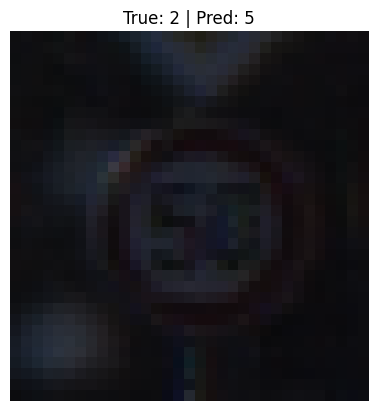

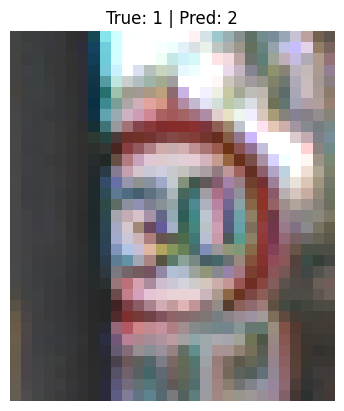

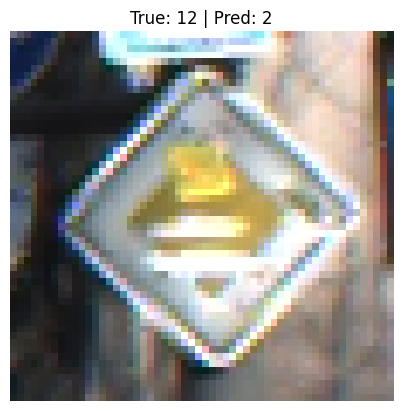

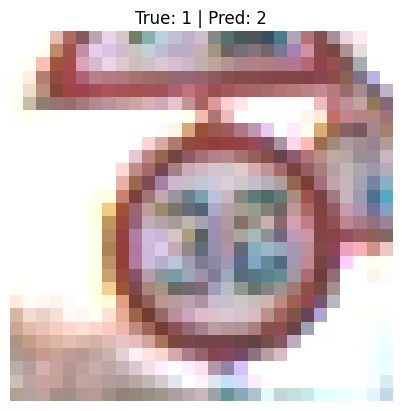

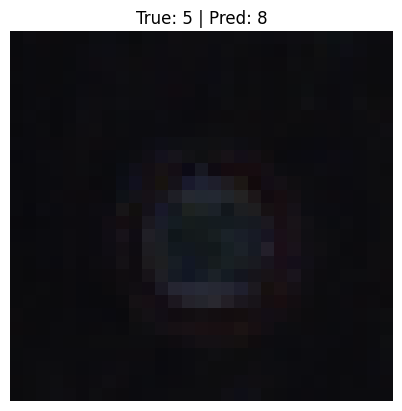

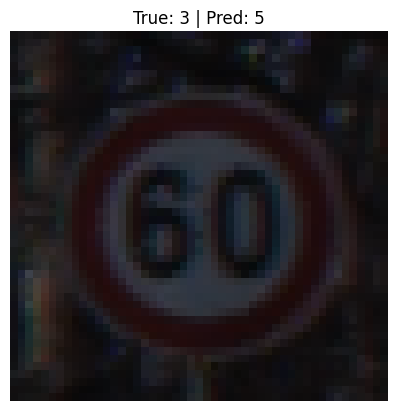

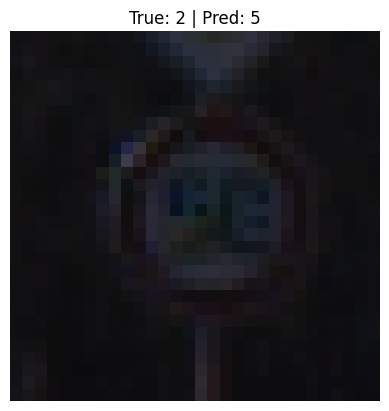

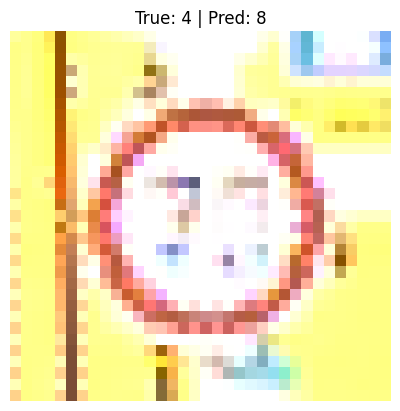

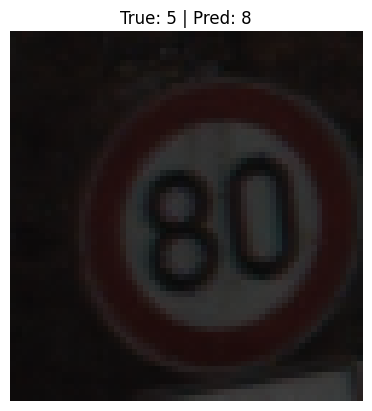

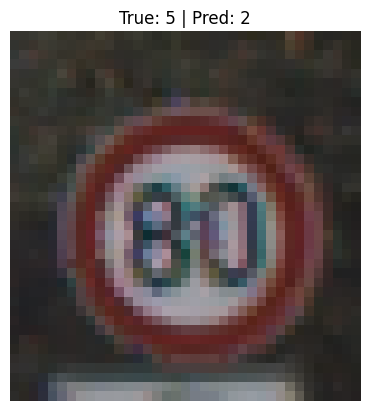

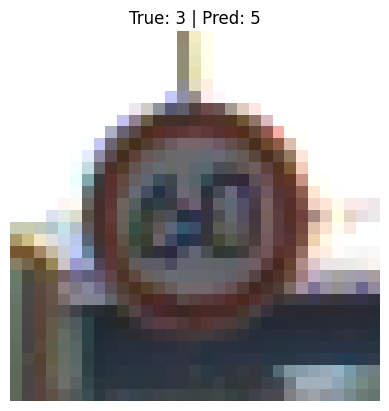

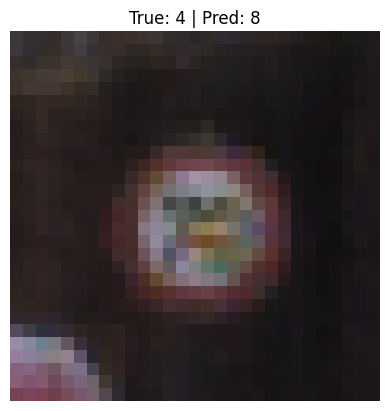

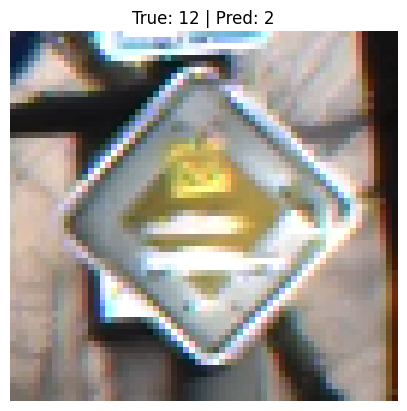

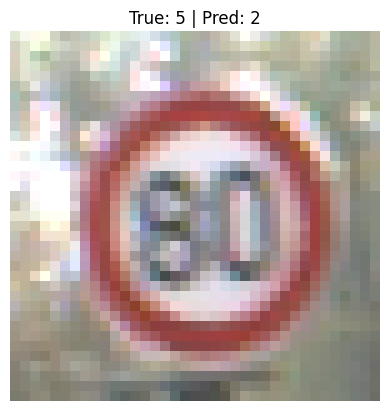

In [ ]:

pairs_with_2_misclass_rf = [pair for pair, count in pair_counts_rf.items() if count == 2]

selected_indices_rf = [i for i, pair in enumerate(misclass_pairs_rf) if pair in pairs_with_2_misclass_rf]

for i in selected_indices_rf:
    img = mpimg.imread(misclassified_paths_rf[i])
    plt.imshow(img)
    plt.title(f"True: {true_labels_rf[i]} | Pred: {pred_labels_rf[i]}")
    plt.axis("off")
    plt.show()

### SVM

In [650]:
pca = PCA(n_components=225)
hog_pca_feats = pca.fit_transform(train_hog_feats)

X_trial = np.hstack([hog_pca_feats, X_train_meanhsv, train_hsv_ch, train_lbp_vars])
y = train_metadata["ClassId"].values
    
X_train_trial, X_val_trial, y_train, y_val = train_test_split(X_trial, y, test_size=0.2, random_state=89, stratify=y)
scaler_all = StandardScaler()
X_train_scaled_trial = scaler_all.fit_transform(X_train_trial)
X_val_scaled_trial = scaler_all.transform(X_val_trial)

### Feature Selection

k = 250, CV Accuracy = 0.9091
k = 260, CV Accuracy = 0.9130
k = 270, CV Accuracy = 0.9180
k = 280, CV Accuracy = 0.9185
k = 290, CV Accuracy = 0.9203
k = 300, CV Accuracy = 0.9239
k = 310, CV Accuracy = 0.9255
k = 320, CV Accuracy = 0.9285
k = 330, CV Accuracy = 0.9278
k = 340, CV Accuracy = 0.9276
k = 350, CV Accuracy = 0.9253
k = 360, CV Accuracy = 0.9255
k = 370, CV Accuracy = 0.9253
k = 380, CV Accuracy = 0.9255
k = 390, CV Accuracy = 0.9269
k = 400, CV Accuracy = 0.9260
k = 410, CV Accuracy = 0.9244
k = 420, CV Accuracy = 0.9216


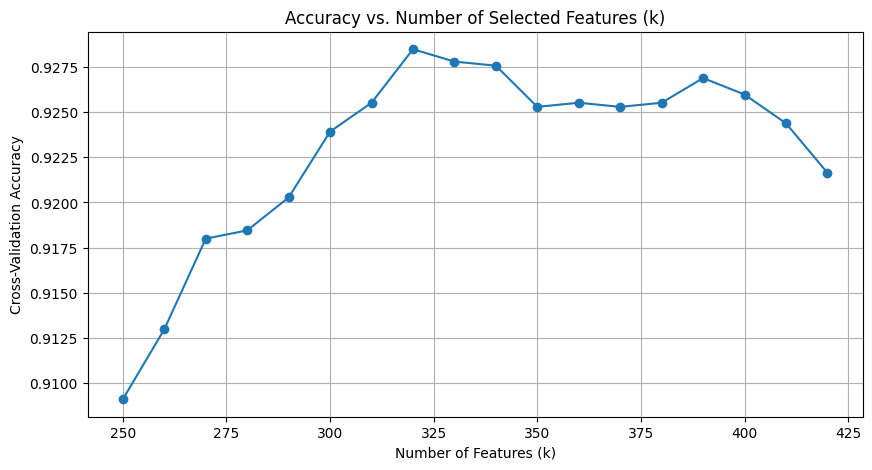

In [653]:
k_values = list(range(250, min(X_val_scaled_trial.shape[1], 450), 10))
cv_scores = []

# Define model
model = SVC(kernel='rbf', C=10, gamma=0.001)

# Evaluate each k
for k in k_values:
    selector = SelectKBest(score_func=lambda X, y: mutual_info_classif(X, y, random_state=42), k=k)
    pipeline = Pipeline([
        ('select', selector),
        ('clf', model)
    ])
    
    scores = cross_val_score(pipeline, X_train_scaled_trial, y_train, cv=5)
    avg_score = np.mean(scores)
    cv_scores.append(avg_score)
    print(f"k = {k}, CV Accuracy = {avg_score:.4f}")

# Step 6: Plot results
plt.figure(figsize=(10, 5))
plt.plot(k_values, cv_scores, marker='o')
plt.title('Accuracy vs. Number of Selected Features (k)')
plt.xlabel('Number of Features (k)')
plt.ylabel('Cross-Validation Accuracy')
plt.grid(True)
plt.show()

In [ ]:
pca = PCA(n_components=225)
hog_pca_feats = pca.fit_transform(train_hog_feats)

X_trial = np.hstack([hog_pca_feats, X_train_meanhsv, train_hsv_ch, train_lbp_vars])
y = train_metadata["ClassId"].values
    
X_train_trial, X_val_trial, y_train, y_val = train_test_split(X_trial, y, test_size=0.2, random_state=89, stratify=y)
scaler_all = StandardScaler()
X_train_scaled_trial = scaler_all.fit_transform(X_train_trial)
X_val_scaled_trial = scaler_all.transform(X_val_trial)
k_best = 320
selector = SelectKBest(score_func=lambda X, y: mutual_info_classif(X, y, random_state=42), k=k_best)

# Fit selector on training data
X_train_selected_svm = selector.fit_transform(X_train_scaled_svm, y_train)
X_val_selected_svm = selector.transform(X_val_scaled_svm)

In [506]:
param_grid = {
    'C': [5, 10, 25, 30,35],
    'gamma': [0.0005,0.0008, 0.001, 0.005]
}

grid = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5)
grid.fit(X_train_selected_svm , y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-val accuracy:", grid.best_score_)

Best parameters: {'C': 25, 'gamma': 0.001}
Best cross-val accuracy: 0.9271070615034169


In [28]:
pca = PCA(n_components=225)
hog_pca_feats = pca.fit_transform(train_hog_feats)

# Step 2: Combine all features
Xtrain_svm = np.hstack([hog_pca_feats, X_train_meanhsv, train_hsv_ch, train_lbp_vars])
y = train_metadata["ClassId"].values

# Step 3: Train-validation split
X_train_svm, X_val_svm, y_train, y_val, idx_train_svm, idx_val_svm  = train_test_split(Xtrain_svm , y, np.arange(len(Xtrain_svm)), test_size=0.2, random_state=89, stratify=y)

# Step 4: Scaling
scaler_all = StandardScaler()
X_train_scaled_svm = scaler_all.fit_transform(X_train_svm)
X_val_scaled_svm = scaler_all.transform(X_val_svm)

# Step 5: Feature selection using optimal k
k_best = 320
selector = SelectKBest(score_func=lambda X, y: mutual_info_classif(X, y, random_state=42), k=k_best)

# Fit selector on training data
X_train_selected_svm = selector.fit_transform(X_train_scaled_svm, y_train)
X_val_selected_svm = selector.transform(X_val_scaled_svm)

# Step 6: Define and train final model
svm_model = SVC(kernel='rbf', C=25, gamma=0.001, probability=True, class_weight = 'balanced')
svm_model.fit(X_train_selected_svm, y_train)

# Step 7: Evaluate
train_acc = svm_model.score(X_train_selected_svm, y_train)
val_acc = svm_model.score(X_val_selected_svm, y_val)
cv_acc = np.mean(cross_val_score(svm_model, X_train_selected_svm, y_train, cv=5))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Cross-Validation Accuracy (CV=5): {cv_acc:.4f}")

Training Accuracy: 1.0000
Validation Accuracy: 0.9408
Cross-Validation Accuracy (CV=5): 0.9228


In [29]:
y_pred_svm= svm_model.predict(X_val_selected_svm)
print(classification_report(y_val, y_pred_svm, digits=4))

              precision    recall  f1-score   support

           0     0.8571    1.0000    0.9231         6
           1     0.8462    0.8871    0.8661        62
           2     0.8310    0.9365    0.8806        63
           3     0.9167    0.8462    0.8800        39
           4     0.9444    0.9273    0.9358        55
           5     0.8182    0.8654    0.8411        52
           6     1.0000    1.0000    1.0000        12
           7     0.9737    0.9250    0.9487        40
           8     0.8571    0.9231    0.8889        39
           9     1.0000    0.9512    0.9750        41
          10     0.9821    0.9821    0.9821        56
          11     0.9722    0.9459    0.9589        37
          12     0.9833    1.0000    0.9916        59
          13     1.0000    1.0000    1.0000        60
          14     1.0000    1.0000    1.0000        22
          15     1.0000    1.0000    1.0000        18
          16     1.0000    0.8333    0.9091        12
          17     1.0000    

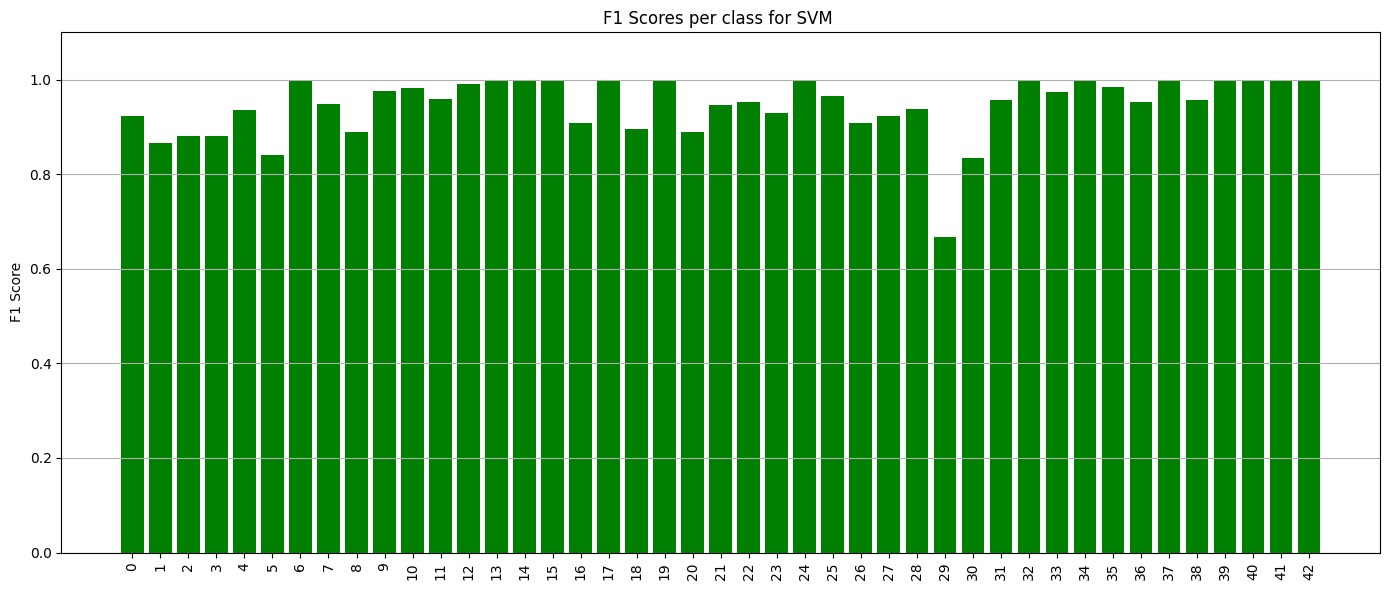

In [30]:
f1_scores = f1_score(y_val, y_pred_svm, average=None)

plt.figure(figsize=(14,6))
plt.bar(range(len(class_names)), f1_scores, color='green')
plt.xticks(range(len(class_names)), class_names, rotation=90)
plt.ylabel("F1 Score")
plt.title("F1 Scores per class for SVM ")
plt.ylim(0, 1.1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Number of misclassified samples: 63


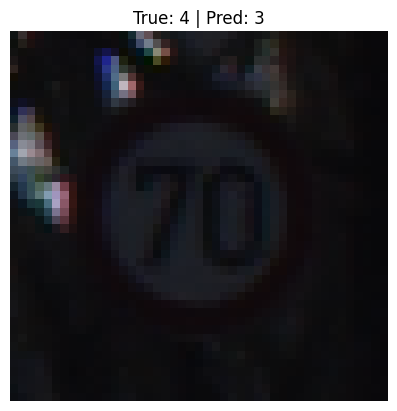

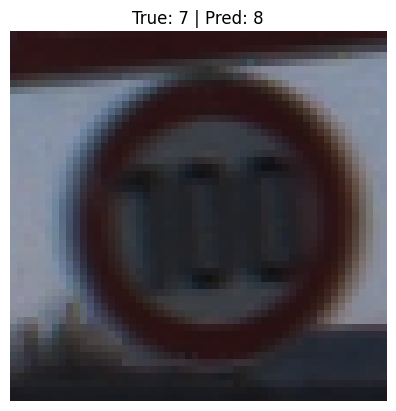

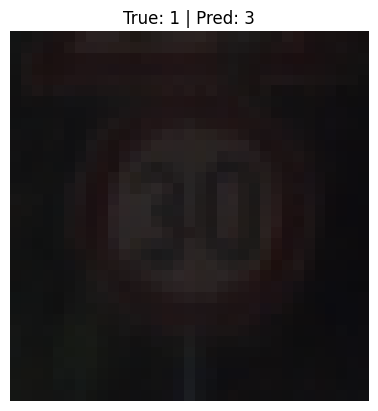

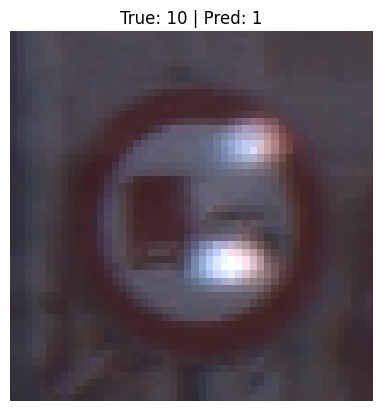

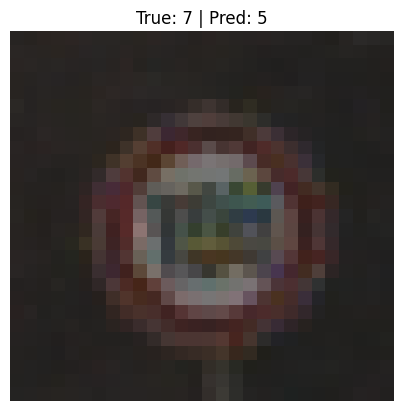

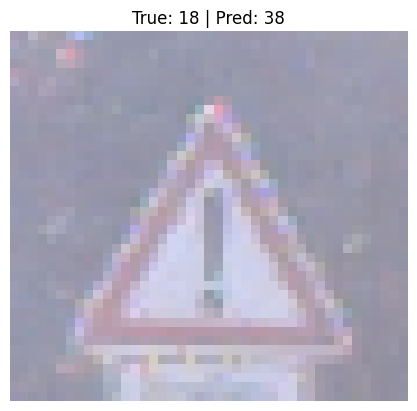

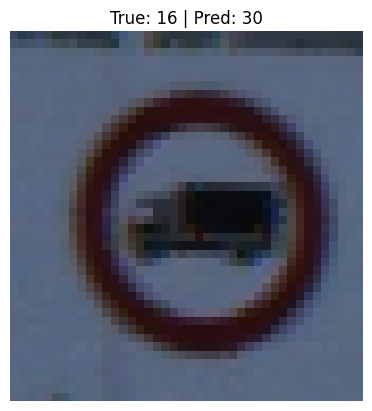

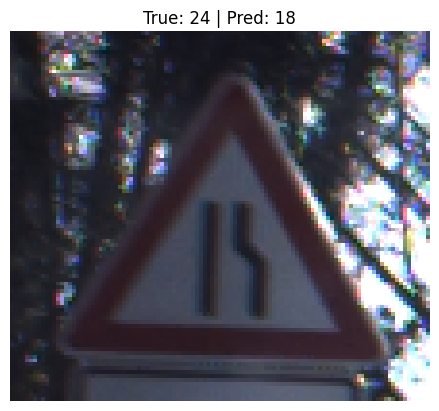

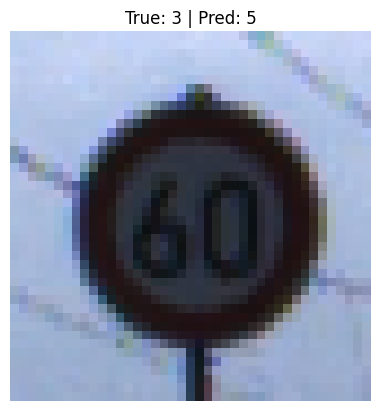

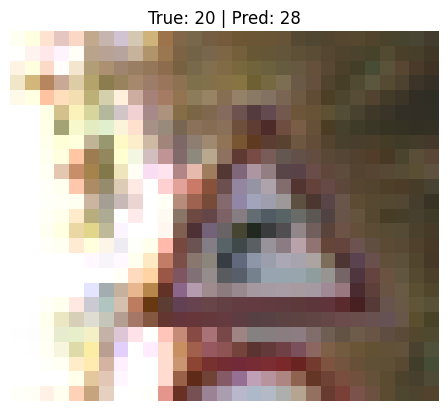

In [694]:
misclassified_idx = np.where(y_pred_svm != y_val)[0]

num_misclassified = misclassified_idx.shape[0]
print("Number of misclassified samples:", num_misclassified)
misclassified_orig_idx = idx_val_svm[misclassified_idx]

misclassified_paths = train_metadata.loc[misclassified_orig_idx, "image_path"].values
true_labels = y_val[misclassified_idx]
pred_labels = y_pred_svm[misclassified_idx]

import matplotlib.image as mpimg

for i in range(min(10, len(misclassified_paths))):
    img = mpimg.imread(misclassified_paths[i])
    plt.imshow(img)
    plt.title(f"True: {true_labels[i]} | Pred: {pred_labels[i]}")
    plt.axis("off")
    plt.show()

In [ ]:

misclass_pairs = list(zip(true_labels, pred_labels))


pair_counts = Counter(misclass_pairs)


misclass_df = pd.DataFrame(pair_counts.items(), columns=["(True, Pred)", "Count"])
misclass_df = misclass_df.sort_values("Count", ascending=False)

print("Most common misclassifications:")
print(misclass_df.head(10))

Most common misclassifications:
   (True, Pred)  Count
8        (3, 5)      3
1        (7, 8)      3
31       (2, 5)      3
12       (1, 2)      3
24       (5, 2)      2
30       (5, 8)      2
18     (29, 31)      2
28       (3, 2)      2
13     (26, 18)      2
5      (18, 38)      2


Most common misclassifications:
   (True, Pred)  Count
17       (4, 8)      2
1        (2, 5)      2
16       (3, 5)      2
6        (1, 2)      2
7       (12, 2)      2
14       (5, 8)      2
24       (5, 2)      2
26     (18, 25)      1
22      (5, 10)      1
23      (40, 7)      1

In [ ]:

misclass_pairs = list(zip(true_labels, pred_labels))


pair_counts = Counter(misclass_pairs)

pairs_with_3_misclass = [pair for pair, count in pair_counts.items() if count == 4]


selected_indices = [i for i, pair in enumerate(misclass_pairs) if pair in pairs_with_3_misclass]
for i in selected_indices:
    img = mpimg.imread(misclassified_paths[i])
    plt.imshow(img)
    plt.title(f"True: {true_labels[i]} | Pred: {pred_labels[i]}")
    plt.axis("off")
    plt.show()

### CNN

In [ ]:
NUM_CLASSES = train_metadata["ClassId"].nunique()

IMG_SIZE = (32, 32)

# Load and preprocess images
def load_and_preprocess(path):
    img = cv2.imread(path)
    resized = cv2.resize(img, IMG_SIZE)
    blurred = cv2.GaussianBlur(resized, (5, 5), 0)
    gray = cv2.cvtColor(blurred, cv2.COLOR_BGR2GRAY)
    equalized = cv2.equalizeHist(gray)
    normalized = equalized / 255.0  
    return normalized


os.chdir("/Users/tasneemzulaiqa/Desktop/university/ML/2025_A2/train")
train_images_cnn = np.array([load_and_preprocess(p) for p in train_metadata["image_path"]])
train_images_cnn = train_images_cnn[..., np.newaxis]  # add channel dimension for grayscale
train_labels_cnn = to_categorical(train_metadata["ClassId"], num_classes=NUM_CLASSES)


In [34]:
X_train_cnn, X_val_cnn, y_train_cnn, y_val_cnn = train_test_split(train_images_cnn , train_labels_cnn, test_size=0.2, random_state=89, stratify = y)


cnn_model = Sequential([
    Conv2D(32, (5, 5), activation='relu', padding='same', input_shape=(*IMG_SIZE, 1)),
    Conv2D(32, (5, 5), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(64, (5, 5), activation='relu', padding='same'),
    Conv2D(64, (5, 5), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])


cnn_model.compile(optimizer='RMSprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1
)

datagen.fit(X_train_cnn)

history = cnn_model.fit(datagen.flow(X_train_cnn, y_train_cnn, batch_size=64),
                    validation_data=(X_val_cnn, y_val_cnn),
                    epochs=30)

Epoch 1/30


/Users/tasneemzulaiqa/Desktop/university/ML/tfenv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/tasneemzulaiqa/Desktop/university/ML/tfenv/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - accuracy: 0.0490 - loss: 3.6286 - val_accuracy: 0.0756 - val_loss: 3.4790
Epoch 2/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.0867 - loss: 3.4562 - val_accuracy: 0.2887 - val_loss: 2.7120
Epoch 3/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step - accuracy: 0.1969 - loss: 2.9626 - val_accuracy: 0.4791 - val_loss: 1.9541
Epoch 4/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 128ms/step - accuracy: 0.3350 - loss: 2.3424 - val_accuracy: 0.5483 - val_loss: 1.5587
Epoch 5/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 129ms/step - accuracy: 0.4300 - loss: 1.9442 - val_accuracy: 0.6375 - val_loss: 1.1504
Epoch 6/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 11s 157ms/step - accuracy: 0.5177 - loss: 1.6158 - val_accuracy: 0.7750 - val_loss: 0.7782
Epoch 7/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 144ms/step - accuracy: 0.6078 - loss: 1.3169 - val_accuracy: 0.8370 - val_loss: 0.5614
Epoch 8/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - accuracy: 0.6816 - loss: 1.0529 - val_accuracy: 0.8543 - va

In [35]:
val_loss, val_accuracy = cnn_model.evaluate(X_val_cnn, y_val_cnn)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")


# Access training accuracy
train_accuracies = history.history['accuracy']
val_accuracies = history.history['val_accuracy']

# Last epoch's training accuracy
final_train_accuracy = train_accuracies[-1]

print(f"Final Training Accuracy: {final_train_accuracy:.4f}")


35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9831 - loss: 0.0680
Validation Loss: 0.0765
Validation Accuracy: 0.9791
Final Training Accuracy: 0.9330


In [36]:
cnn_prob = cnn_model.predict(X_val_cnn)
# Convert predicted probabilities to class labels
y_pred_labels_svm = np.argmax(cnn_prob, axis=1)
y_val_labels = np.argmax(y_val_cnn, axis=1)

# Generate and print classification report
print(classification_report(y_val_labels , y_pred_labels_svm, digits=4))

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
              precision    recall  f1-score   support

           0     1.0000    0.8333    0.9091         6
           1     0.9394    1.0000    0.9688        62
           2     1.0000    0.9683    0.9839        63
           3     0.9250    0.9487    0.9367        39
           4     1.0000    1.0000    1.0000        55
           5     0.9800    0.9423    0.9608        52
           6     0.9231    1.0000    0.9600        12
           7     0.9524    1.0000    0.9756        40
           8     1.0000    1.0000    1.0000        39
           9     1.0000    1.0000    1.0000        41
          10     1.0000    1.0000    1.0000        56
          11     0.9487    1.0000    0.9737        37
          12     1.0000    0.9831    0.9915        59
          13     1.0000    1.0000    1.0000        60
          14     1.0000    1.0000    1.0000        22
          15     1.0000    0.9444    0.9714        18
          16     1.0000    1.0000    1.00

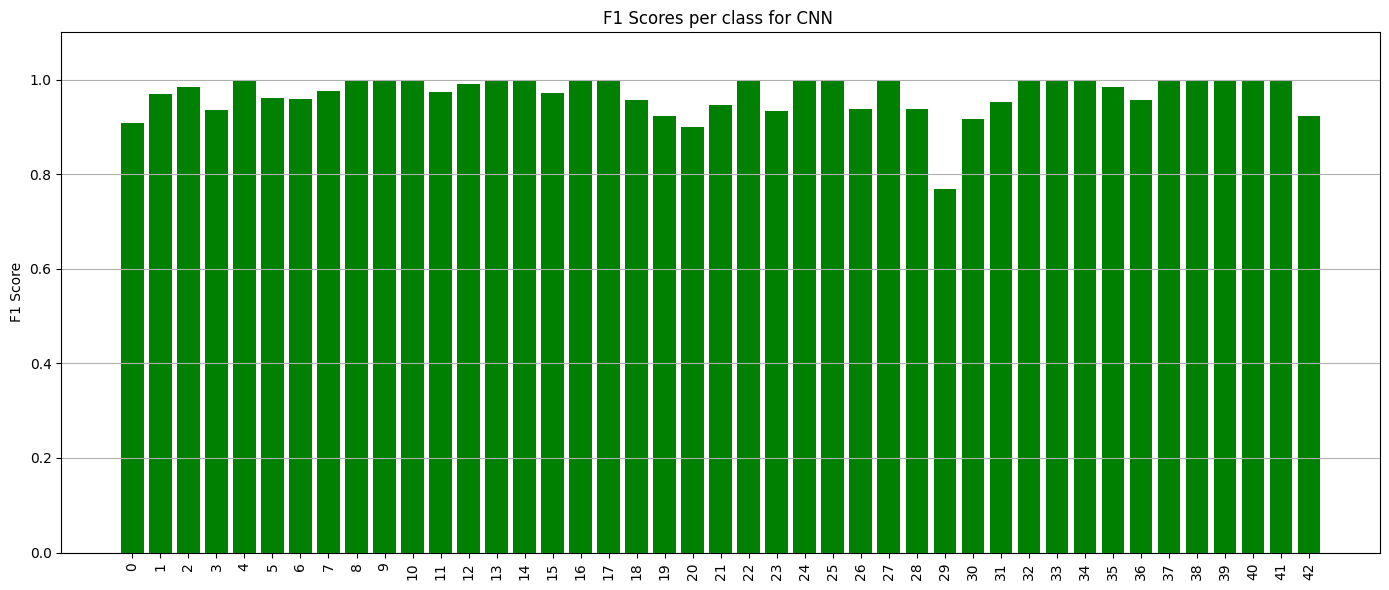

In [38]:
f1_scores = f1_score(y_val_labels, y_pred_labels_svm, average=None)

plt.figure(figsize=(14,6))
plt.bar(range(len(class_names)), f1_scores, color='green')
plt.xticks(range(len(class_names)), class_names, rotation=90)
plt.ylabel("F1 Score")
plt.title("F1 Scores per class for CNN ")
plt.ylim(0, 1.1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


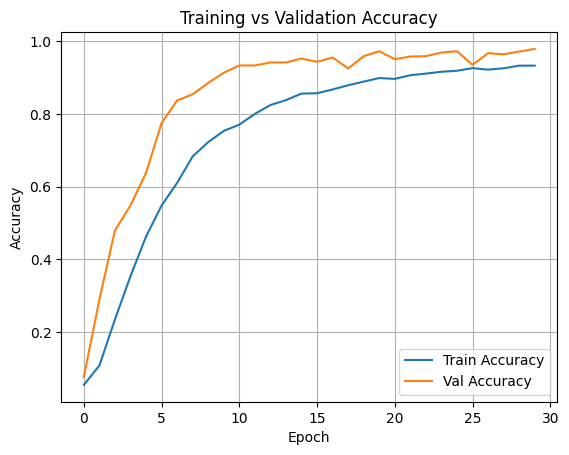

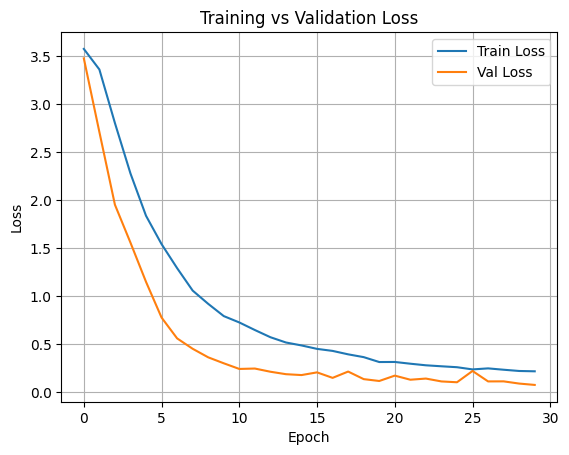

In [39]:
# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

## STACKING MODEL

In [40]:
svm_train_preds = svm_model.predict_proba(X_train_selected_svm)
rf_train_preds = rf_model.predict_proba(X_train_scaled_rf)
cnn_train_preds = cnn_model.predict(X_train_cnn)

svm_val_preds = svm_model.predict_proba(X_val_selected_svm)
rf_val_preds = rf_model.predict_proba(X_val_scaled_rf )
cnn_val_preds = cnn_model.predict(X_val_cnn)

138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


In [41]:

# Try different combinations
combinations = {
    "SVM + CNN": np.hstack([svm_val_preds, cnn_val_preds]),
    "CNN + RF": np.hstack([cnn_val_preds, rf_val_preds]),
    "SVM + RF": np.hstack([svm_val_preds, rf_val_preds]),
    "SVM + CNN + RF": np.hstack([svm_val_preds, cnn_val_preds, rf_val_preds])
}

# Train corresponding meta-models and evaluate
print("Validation Accuracies for different model combinations:")
for name, meta_X_val in combinations.items():
    # Match the training inputs to the validation structure
    if name == "SVM + CNN":
        meta_X_train = np.hstack([svm_train_preds, cnn_train_preds])
    elif name == "CNN + RF":
        meta_X_train = np.hstack([cnn_train_preds, rf_train_preds])
    elif name == "SVM + RF":
        meta_X_train = np.hstack([svm_train_preds, rf_train_preds])
    else:
        meta_X_train = np.hstack([svm_train_preds, cnn_train_preds, rf_train_preds])

    meta_model = LogisticRegression(max_iter=100)
    meta_model.fit(meta_X_train, y_train)

    val_acc = meta_model.score(meta_X_val, y_val)
    print(f"{name}: {val_acc:.4f}")

Validation Accuracies for different model combinations:
SVM + CNN: 0.9827
CNN + RF: 0.9800
SVM + RF: 0.9617
SVM + CNN + RF: 0.9891


In [42]:
# Get prediction probabilities on training data
svm_train_preds = svm_model.predict_proba(X_train_selected_svm)
rf_train_preds = rf_model.predict_proba(X_train_scaled_rf)
cnn_train_preds = cnn_model.predict(X_train_cnn)


#  Stack predictions as new features
meta_X_train = np.hstack([svm_train_preds, cnn_train_preds, rf_train_preds])
 
#  Train meta-model
meta_model = LogisticRegression(max_iter=100)
meta_model.fit(meta_X_train, y_train)

# Step 4: Validation
svm_val_preds = svm_model.predict_proba(X_val_selected_svm)
rf_val_preds = rf_model.predict_proba(X_val_scaled_rf )
cnn_val_preds = cnn_model.predict(X_val_cnn)

meta_X_val = np.hstack([svm_val_preds, cnn_val_preds, rf_val_preds])
val_acc = meta_model.score(meta_X_val, y_val)
train_acc = meta_model.score(meta_X_train, y_train)

# see training accuracy
train_acc


138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


1.0

In [43]:

y_pred_meta = meta_model.predict(meta_X_val)
print(classification_report(y_val, y_pred_meta, digits=4))

              precision    recall  f1-score   support

           0     1.0000    0.8333    0.9091         6
           1     0.9688    1.0000    0.9841        62
           2     0.9841    0.9841    0.9841        63
           3     1.0000    0.9487    0.9737        39
           4     1.0000    1.0000    1.0000        55
           5     0.9811    1.0000    0.9905        52
           6     1.0000    1.0000    1.0000        12
           7     1.0000    1.0000    1.0000        40
           8     1.0000    1.0000    1.0000        39
           9     1.0000    1.0000    1.0000        41
          10     1.0000    1.0000    1.0000        56
          11     0.9487    1.0000    0.9737        37
          12     1.0000    1.0000    1.0000        59
          13     1.0000    1.0000    1.0000        60
          14     1.0000    1.0000    1.0000        22
          15     1.0000    1.0000    1.0000        18
          16     1.0000    1.0000    1.0000        12
          17     1.0000    

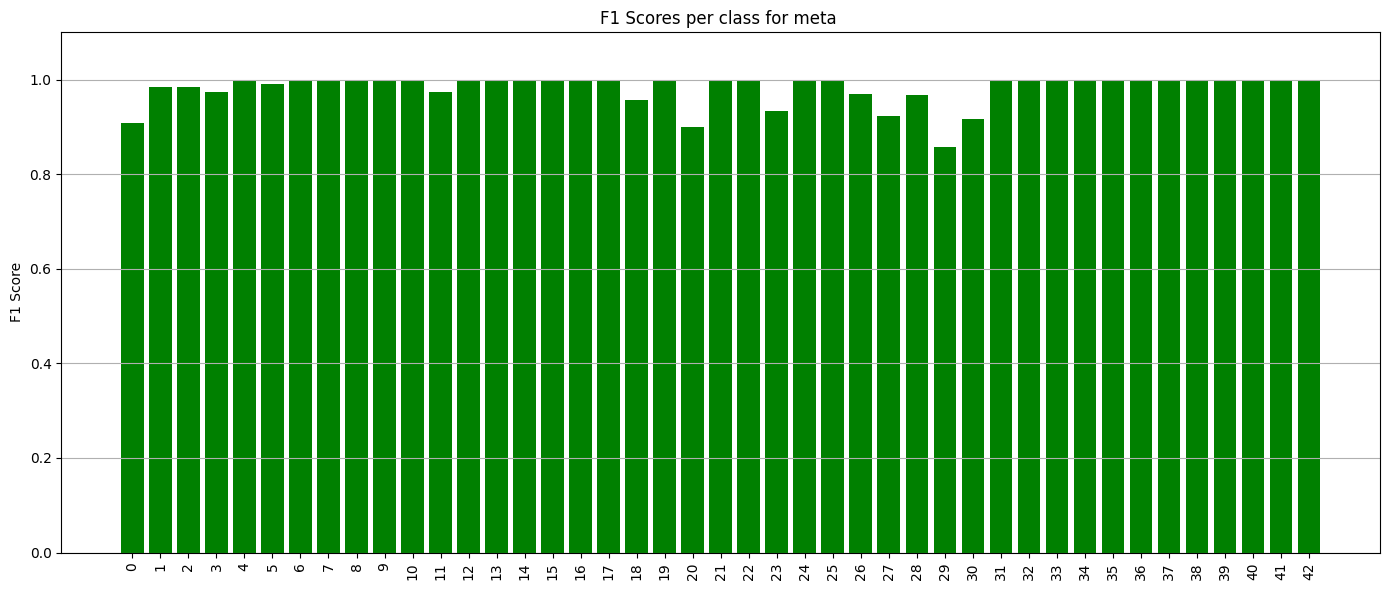

In [44]:
f1_scores = f1_score(y_val, y_pred_meta, average=None)

plt.figure(figsize=(14,6))
plt.bar(range(len(class_names)), f1_scores, color='green')
plt.xticks(range(len(class_names)), class_names, rotation=90)
plt.ylabel("F1 Score")
plt.title("F1 Scores per class for meta ")
plt.ylim(0, 1.1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### EVALUATION  ON TEST SET

RANDOM FOREST

In [536]:
os.chdir("/Users/tasneemzulaiqa/Desktop/university/ML/2025_A2/test")
test_metadata = pd.read_csv("test_metadata.csv")
os.getcwd()
test_df_meanrgb = pd.read_csv("Features/additional_features.csv")

IMG_SIZE = (64, 64)
test_images = [load_image(p) for p in test_metadata['image_path']]
processed_test_images = [preprocess_image(img) for img in test_images]

# TEXTURE VARIANCE, BLUR SCORE, BRIGHTNESS, CONTRAST
pixel_vars = []
lbp_vars = []
blur_scores = [] 
brightness = []
contrast = []

for img in processed_test_images:
    pv, lbpv = extract_variance_features(img)
    blur = blur_score(img)
    b, c = brightness_contrast(img)
    
    pixel_vars.append(pv)
    lbp_vars.append(lbpv)
    blur_scores.append(blur)
    brightness.append(b) 
    contrast.append(c) 
    
# Convert to arrays and reshape
test_pixel_vars = np.array(pixel_vars).reshape(-1, 1)
test_lbp_vars = np.array(lbp_vars).reshape(-1, 1)
test_blur_scores = np.array(blur_scores).reshape(-1, 1) 
test_brightness = np.array(brightness).reshape(-1, 1)  
test_contrast = np.array(contrast).reshape(-1, 1)

# HOG FEATURE
test_hog_feats = np.array([extract_hog_features(img) for img in processed_test_images])

# HSV STATS AND HISTOGRAM
test_hsv_stats = np.array([extract_hsv_stats(img) for img in test_images])
test_hsv_ch = [hsv_histogram(img) for img in test_images]
X_test_edge_density = test_df_meanrgb.drop(columns=["ClassId", "id", "image_path", "mean_r", "mean_g", "mean_b"], errors="ignore").values
X_test_meanhsv = np.hstack([X_test_edge_density, test_hsv_stats])

In [537]:
# RETRAIN RF

Xtrain_rf = np.hstack([train_hog_feats, X_train_meanhsv, train_hsv_ch, train_lbp_vars])
Xtest_rf = np.hstack([test_hog_feats, X_test_meanhsv, test_hsv_ch, test_lbp_vars])
y = train_metadata["ClassId"].values
    
scaler_all = StandardScaler()
Xtrain_scaled_rf = scaler_all.fit_transform(Xtrain_rf)
Xtest_scaled_rf = scaler_all.transform(Xtest_rf)

rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=None,
    min_samples_split=3,
    min_samples_leaf = 2,
    random_state=42, class_weight = 'balanced'
)

rf_model.fit(Xtrain_scaled_rf, y)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       min_samples_split=3, n_estimators=250, random_state=42)

In [ ]:
# get predictions and save
rf_test_preds = rf_model.predict(Xtest_scaled_rf)

submission = pd.DataFrame({
    "id": test_metadata["id"],  
    "ClassId": rf_test_preds
})

submission.to_csv("submission3_rf.csv", index=False)

### SVM

In [ ]:
# Apply pca to HOG
pca = PCA(n_components=225)
train_hog_pca_feats = pca.fit_transform(train_hog_feats)
test_hog_pca_feats = pca.transform(test_hog_feats)


# Combine all features
X_train_svm = np.hstack([train_hog_pca_feats, X_train_meanhsv, train_hsv_ch, train_lbp_vars])
X_test_svm = np.hstack([test_hog_pca_feats, X_test_meanhsv, test_hsv_ch, test_lbp_vars])
y = train_metadata["ClassId"].values


# Scaling
scaler_all = StandardScaler()
Xtrain_scaled_svm = scaler_all.fit_transform(X_train_svm)
Xtest_scaled_svm = scaler_all.transform(X_test_svm)

# Feature selection using optimal k
k_best = 320
selector = SelectKBest(score_func=lambda X, y: mutual_info_classif(X, y, random_state=42), k=k_best)

# Fit selector on data
Xtrain_selected_svm = selector.fit_transform(Xtrain_scaled_svm, y)
Xtest_selected_svm = selector.transform(Xtest_scaled_svm)

# train final model
svm_model = SVC(kernel='rbf', C=25, gamma=0.001, probability=True)
svm_model.fit(Xtrain_selected_svm, y)

svm_test_preds = svm_model.predict(Xtest_selected_svm)

submission = pd.DataFrame({
    "id": test_metadata["id"], 
    "ClassId": svm_test_preds
})

submission.to_csv("submission3_svm.csv", index=False)



### CNN

In [554]:
os.chdir("/Users/tasneemzulaiqa/Desktop/university/ML/2025_A2/test")
test_images_cnn = np.array([load_and_preprocess(p) for p in test_metadata["image_path"]])
test_images_cnn = test_images_cnn[..., np.newaxis]

In [555]:

cnn_model = Sequential([
    Conv2D(32, (5, 5), activation='relu', padding='same', input_shape=(*IMG_SIZE, 1)),
    Conv2D(32, (5, 5), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(64, (5, 5), activation='relu', padding='same'),
    Conv2D(64, (5, 5), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

cnn_model.compile(optimizer='RMSprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1
)

datagen.fit(train_images_cnn)

history = cnn_model.fit(datagen.flow(train_images_cnn, train_labels_cnn, batch_size=64),
                    epochs=30)

/Users/tasneemzulaiqa/Desktop/university/ML/tfenv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30


/Users/tasneemzulaiqa/Desktop/university/ML/tfenv/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


86/86 ━━━━━━━━━━━━━━━━━━━━ 17s 183ms/step - accuracy: 0.0523 - loss: 3.8216
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 131ms/step - accuracy: 0.0833 - loss: 3.4565
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 15s 177ms/step - accuracy: 0.2235 - loss: 2.8881
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 14s 160ms/step - accuracy: 0.3426 - loss: 2.3016
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 143ms/step - accuracy: 0.4758 - loss: 1.8114
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - accuracy: 0.5520 - loss: 1.5080
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 136ms/step - accuracy: 0.6367 - loss: 1.2126
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - accuracy: 0.6917 - loss: 1.0343
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 148ms/step - accuracy: 0.7225 - loss: 0.9131
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 181ms/step - accuracy: 0.7590 - loss: 0.7762
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 14s 160ms/step - accuracy: 0.7891 - loss: 0.6781
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 153ms/ste

In [556]:
cnn_test_probs = cnn_model.predict(test_images_cnn)
cnn_test_preds = np.argmax(cnn_test_probs, axis=1)

submission = pd.DataFrame({
    "id": test_metadata["id"], 
    "ClassId": cnn_test_preds
})

submission.to_csv("submission3_cnn.csv", index=False)

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


### STACKING  MODEL

In [557]:
# Get prediction probabilities on training data
svm_train_preds = svm_model.predict_proba(Xtrain_selected_svm)
rf_train_preds = rf_model.predict_proba(Xtrain_scaled_rf)
cnn_train_preds = cnn_model.predict(train_images_cnn)

# Stack predictions as new features
meta_X_train = np.hstack([svm_train_preds, rf_train_preds, cnn_train_preds])

# Train meta-model
meta_model = LogisticRegression(max_iter=100)
meta_model.fit(meta_X_train, y)

# Test set
svm_test_preds = svm_model.predict_proba(Xtest_selected_svm)
rf_test_preds = rf_model.predict_proba(Xtest_scaled_rf)
cnn_test_preds = cnn_model.predict(test_images_cnn)

meta_X_test = np.hstack([svm_test_preds, rf_test_preds, cnn_test_preds])
meta_test_preds = meta_model.predict(meta_X_test)  

submission = pd.DataFrame({
    "id": test_metadata["id"], 
    "ClassId": meta_test_preds
})

submission.to_csv("submissionmeta3.csv", index=False)

172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
